In [77]:
# Inputs: processed latest | Process: load SATNAV | Outputs: satnav_df
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML
from pathlib import Path

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

processed_dir = Path("../data/processed")
candidates = sorted(processed_dir.glob("satnav_*.csv"))
csv_path = candidates[-1] if candidates else processed_dir / "satnav_latest.csv"

satnav_df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", satnav_df.shape)

# Inputs: CSV file path | Process: read CSV | Outputs: satnav_tidy DataFrame
from pathlib import Path


# Show all columns (and full column text) when using head(), etc.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

def show_freeze_header(df, height=400):
    html = df.to_html(index=False)
    return HTML(f"""
    <style>
    .scrollbox {{ max-height:{height}px; overflow-y:auto; }}
    .scrollbox thead th {{ position: sticky; top: 0; background: white; z-index: 2; }}
    </style>
    <div class="scrollbox">{html}</div>
    """)


csv_path = Path("../data/processed/satnav_tidy.csv")
satnav_tidy = pd.read_csv(csv_path)
print(f"Loaded: {csv_path.resolve()}")
print(f"Shape: {satnav_tidy.shape}")


Loaded: ../data/processed/satnav_tidy.csv
Shape: (65088, 36)
Loaded: /Users/aaeush/Desktop/Drive/Drive/Academics/Py Project/MyCode/OrbitIQ/orbitiq/data/processed/satnav_tidy.csv
Shape: (65088, 36)


# Inputs: None | Process: Planning bivariate analysis approach | Outputs: Analysis framework

Bivariate analysis: Label + Number

How do orbital/perturbation parameters differ across groups of satellite characteristics?

How do orbital parameters vary by satellite type?

Do launch countries show different orbital characteristics?

Are there temporal trends in specific satellite categories?


# Inputs: Analysis framework | Process: Define categorical-numerical analysis methods | Outputs: Method list

Box plots by category
Violin plots for distribution comparison
Grouped bar charts for means/medians
ANOVA/Kruskal-Wallis tests for group differences
Correlation heatmaps for categorical-numerical relationships

# Inputs: Analysis framework | Process: Define categorical-categorical analysis methods | Outputs: Method list

Contingency tables
Chi-square tests of independence
Mosaic plots
Heatmaps of cross-tabulations
Stacked bar charts

# Inputs: Analysis framework | Process: Define numerical-numerical analysis methods | Outputs: Method list

Scatter plots with trend lines
Correlation matrices
Principal Component Analysis (PCA)
Cluster analysis
Regression analysis

# Inputs: Method lists | Process: Categorical-categorical analysis section | Outputs: Analysis results

# Label+Label Analysis

In [87]:
# Inputs: satnav_tidy, cat1, cat2 | Process: categorical-categorical analysis | Outputs: contingency tables and chi-square tests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chi2
from scipy.stats.contingency import expected_freq
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

def analyze_categorical_categorical(df, cat1, cat2, show_plots=True, top_categories=10):
    """
    Comprehensive categorical-categorical analysis function
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data
    cat1, cat2 : str
        Column names for the two categorical variables
    show_plots : bool, default True
        Whether to display visualizations
    top_categories : int, default 10
        Number of top categories to show in visualizations
    
    Returns:
    --------
    dict : Dictionary containing all analysis results
    """
    
    # Validate inputs
    if cat1 not in df.columns:
        raise ValueError(f"Column '{cat1}' not found in dataframe")
    if cat2 not in df.columns:
        raise ValueError(f"Column '{cat2}' not found in dataframe")
    
    print(f"🔍 CATEGORICAL-CATEGORICAL ANALYSIS: {cat1} vs {cat2}")
    print("=" * 60)
    
    # Create contingency table
    contingency_table = pd.crosstab(df[cat1], df[cat2], margins=True, margins_name="Total")
    
    # Remove margins for statistical analysis
    contingency_table_clean = pd.crosstab(df[cat1], df[cat2])
    
    # Basic information
    print(f"\n📊 BASIC INFORMATION:")
    print(f"   • Dataset shape: {df.shape}")
    print(f"   • {cat1} unique values: {df[cat1].nunique()}")
    print(f"   • {cat2} unique values: {df[cat2].nunique()}")
    print(f"   • Missing values in {cat1}: {df[cat1].isna().sum()}")
    print(f"   • Missing values in {cat2}: {df[cat2].isna().sum()}")
    
    # Display contingency table
    print(f"\n📋 CONTINGENCY TABLE:")
    print(contingency_table)
    
    # Chi-square test of independence
    print(f"\n�� CHI-SQUARE TEST OF INDEPENDENCE:")
    
    # Check if we have enough data for chi-square test
    if contingency_table_clean.shape[0] < 2 or contingency_table_clean.shape[1] < 2:
        print("   ⚠️  Cannot perform chi-square test: need at least 2x2 table")
        chi2_stat, p_value, dof, expected = None, None, None, None
    else:
        # Perform chi-square test
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table_clean)
        
        print(f"   • Chi-square statistic: {chi2_stat:.4f}")
        print(f"   • Degrees of freedom: {dof}")
        print(f"   • p-value: {p_value:.6f}")
        print(f"   • Significance level: {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
        
        # Interpretation
        if p_value < 0.05:
            print(f"   ✅ Result: Variables are DEPENDENT (p < 0.05)")
        else:
            print(f"   ❌ Result: Variables are INDEPENDENT (p ≥ 0.05)")
    
    # Expected frequencies
    if expected is not None:
        print(f"\n�� EXPECTED FREQUENCIES:")
        expected_df = pd.DataFrame(expected, 
                                 index=contingency_table_clean.index, 
                                 columns=contingency_table_clean.columns)
        print(expected_df.round(2))
        
        # Residuals (observed - expected)
        residuals = contingency_table_clean - expected_df
        print(f"\n📉 RESIDUALS (Observed - Expected):")
        print(residuals.round(2))
    
    # Proportions analysis
    print(f"\n📊 PROPORTIONS ANALYSIS:")
    
    # Row proportions (proportion of each cat1 category that falls into each cat2 category)
    row_props = pd.crosstab(df[cat1], df[cat2], normalize='index') * 100
    print(f"\nRow proportions (% of {cat1} in each {cat2} category):")
    print(row_props.round(2))
    
    # Column proportions (proportion of each cat2 category that falls into each cat1 category)
    col_props = pd.crosstab(df[cat1], df[cat2], normalize='columns') * 100
    print(f"\nColumn proportions (% of {cat2} in each {cat1} category):")
    print(col_props.round(2))
    
    # Visualizations
    if show_plots:
        print(f"\n�� VISUALIZATIONS:")
        
        # Get top categories for cleaner visualizations
        top_cat1 = df[cat1].value_counts().head(top_categories).index
        top_cat2 = df[cat2].value_counts().head(top_categories).index
        
        # Filter data for top categories
        df_filtered = df[df[cat1].isin(top_cat1) & df[cat2].isin(top_cat2)]
        
        if len(df_filtered) > 0:
            # Create figure with subplots
            fig, axes = plt.subplots(2, 2, figsize=(16, 12))
            fig.suptitle(f'Categorical Analysis: {cat1} vs {cat2}', fontsize=16, fontweight='bold')
            
            # 1. Heatmap of contingency table
            contingency_plot = pd.crosstab(df_filtered[cat1], df_filtered[cat2])
            sns.heatmap(contingency_plot, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
            axes[0,0].set_title(f'Contingency Table Heatmap\n(Top {top_categories} categories each)')
            axes[0,0].tick_params(axis='x', rotation=45)
            axes[0,0].tick_params(axis='y', rotation=0)
            
            # 2. Stacked bar chart
            contingency_plot.plot(kind='bar', stacked=True, ax=axes[0,1], colormap='tab20')
            axes[0,1].set_title(f'Stacked Bar Chart\n(Top {top_categories} categories each)')
            axes[0,1].tick_params(axis='x', rotation=45)
            axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            
            # 3. Normalized stacked bar chart (proportions)
            contingency_norm = pd.crosstab(df_filtered[cat1], df_filtered[cat2], normalize='index')
            contingency_norm.plot(kind='bar', stacked=True, ax=axes[1,0], colormap='tab20')
            axes[1,0].set_title(f'Normalized Stacked Bar Chart\n(Proportions by {cat1})')
            axes[1,0].tick_params(axis='x', rotation=45)
            axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            
            # 4. Mosaic plot (if we have reasonable number of categories)
            if len(top_cat1) <= 8 and len(top_cat2) <= 8:
                try:
                    from statsmodels.graphics.mosaicplot import mosaic
                    mosaic_data = df_filtered[[cat1, cat2]].dropna()
                    mosaic(mosaic_data, [cat1, cat2], ax=axes[1,1], title=f'Mosaic Plot\n(Top {top_categories} categories each)')
                except ImportError:
                    # Fallback to count plot if mosaic plot not available
                    sns.countplot(data=df_filtered, x=cat1, hue=cat2, ax=axes[1,1])
                    axes[1,1].set_title(f'Count Plot\n(Top {top_categories} categories each)')
                    axes[1,1].tick_params(axis='x', rotation=45)
            else:
                # Count plot for many categories
                sns.countplot(data=df_filtered, x=cat1, hue=cat2, ax=axes[1,1])
                axes[1,1].set_title(f'Count Plot\n(Top {top_categories} categories each)')
                axes[1,1].tick_params(axis='x', rotation=45)
            
            plt.tight_layout()
            plt.show()
        else:
            print("   ⚠️  No data available for visualization after filtering")
    
    # Summary statistics
    print(f"\n📋 SUMMARY:")
    print(f"   • Total observations: {len(df)}")
    print(f"   • Valid observations: {len(df.dropna(subset=[cat1, cat2]))}")
    print(f"   • Most common {cat1}: {df[cat1].mode().iloc[0] if not df[cat1].mode().empty else 'N/A'}")
    print(f"   • Most common {cat2}: {df[cat2].mode().iloc[0] if not df[cat2].mode().empty else 'N/A'}")
    
    # Return results dictionary
    results = {
        'contingency_table': contingency_table,
        'contingency_table_clean': contingency_table_clean,
        'chi2_statistic': chi2_stat,
        'p_value': p_value,
        'degrees_of_freedom': dof,
        'expected_frequencies': expected_df if expected is not None else None,
        'residuals': residuals if expected is not None else None,
        'row_proportions': row_props,
        'column_proportions': col_props,
        'is_significant': p_value < 0.05 if p_value is not None else None
    }
    
    return results

# Example usage and test the function
print("🚀 CATEGORICAL-CATEGORICAL ANALYSIS FUNCTION READY!")
print("\nExample usage:")
print("results = analyze_categorical_categorical(satnav_tidy, 'object_type', 'rcs_size')")
print("results = analyze_categorical_categorical(satnav_tidy, 'COUNTRY', 'object_type')")

🚀 CATEGORICAL-CATEGORICAL ANALYSIS FUNCTION READY!

Example usage:
results = analyze_categorical_categorical(satnav_tidy, 'object_type', 'rcs_size')
results = analyze_categorical_categorical(satnav_tidy, 'COUNTRY', 'object_type')


🔍 CATEGORICAL-CATEGORICAL ANALYSIS: object_type vs rcs_size

📊 BASIC INFORMATION:
   • Dataset shape: (65088, 47)
   • object_type unique values: 4
   • rcs_size unique values: 3
   • Missing values in object_type: 0
   • Missing values in rcs_size: 10480

📋 CONTINGENCY TABLE:
rcs_size     LARGE  MEDIUM  SMALL  Total
object_type                             
DEBRIS        1360    5197  23075  29632
PAYLOAD      14965    2725   1612  19302
ROCKET BODY   4162     564     34   4760
UNKNOWN        124     453    337    914
Total        20611    8939  25058  54608

�� CHI-SQUARE TEST OF INDEPENDENCE:
   • Chi-square statistic: 35405.8821
   • Degrees of freedom: 6
   • p-value: 0.000000
   • Significance level: ***
   ✅ Result: Variables are DEPENDENT (p < 0.05)

�� EXPECTED FREQUENCIES:
rcs_size        LARGE   MEDIUM     SMALL
object_type                             
DEBRIS       11184.17  4850.58  13597.25
PAYLOAD       7285.26  3159.62   8857.12
ROCKET BODY   1796.59   779.18   2184.22
UN

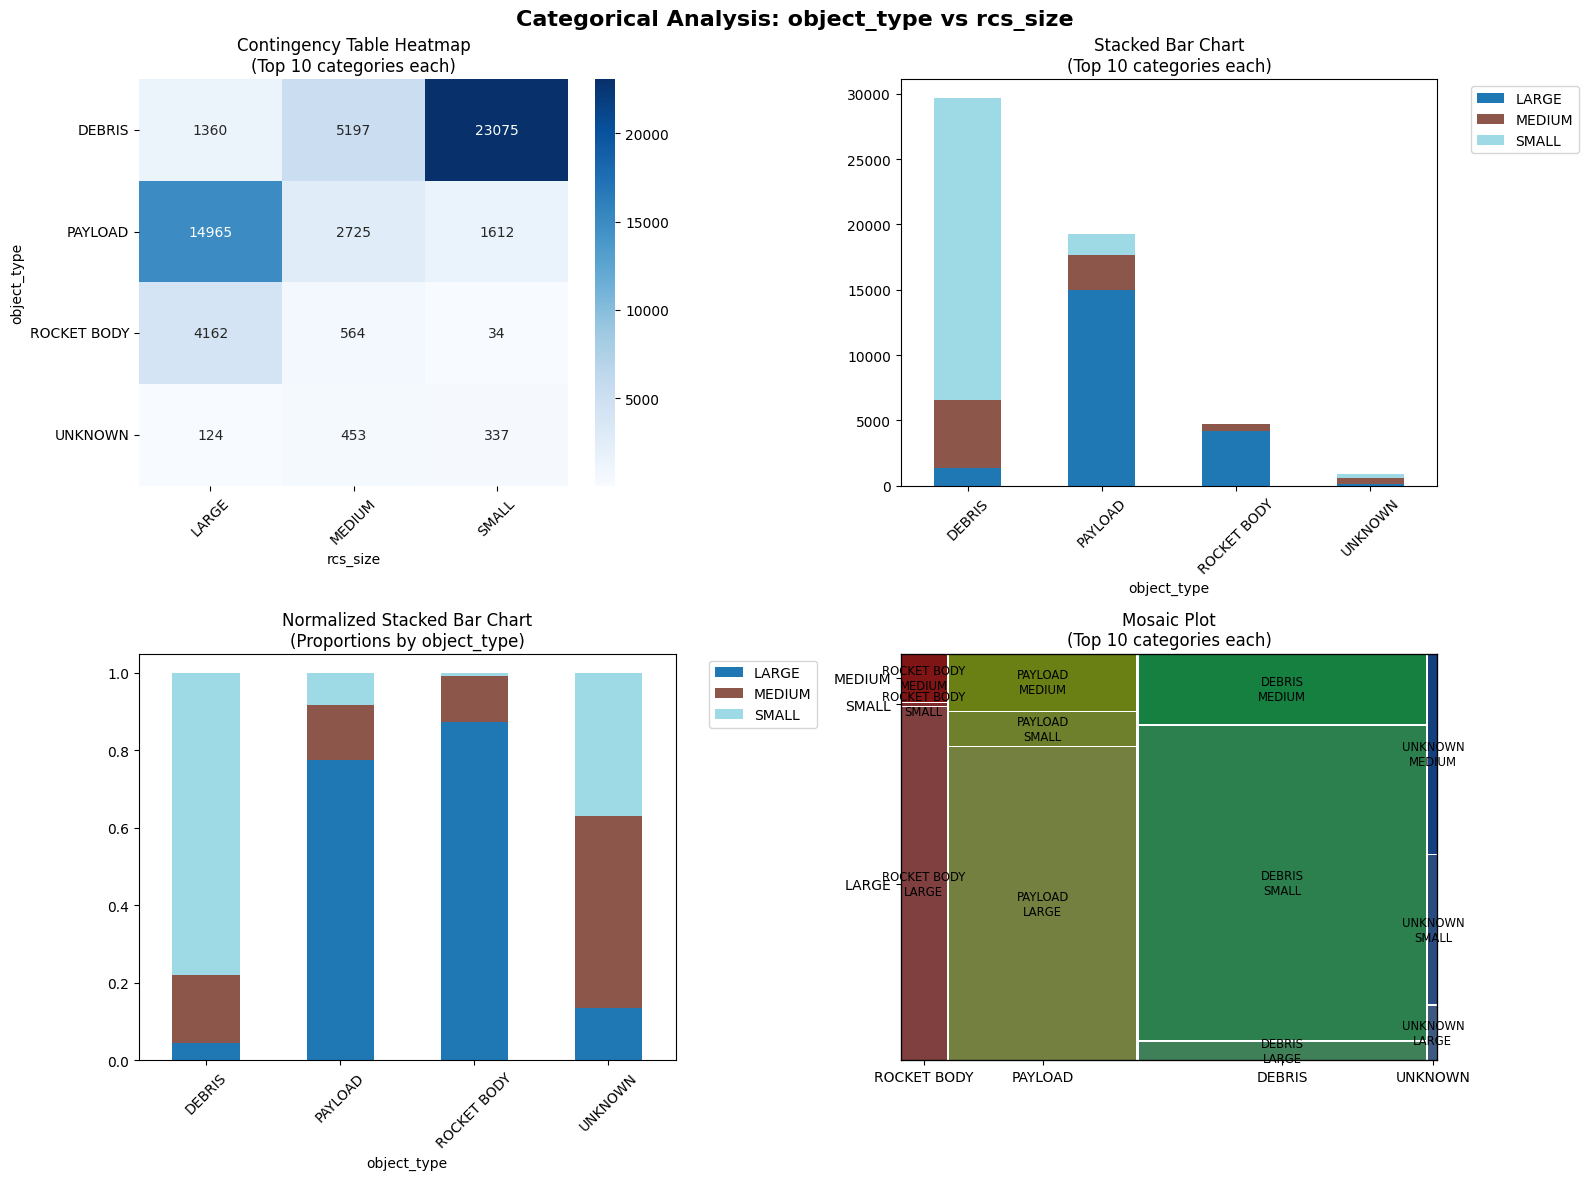


📋 SUMMARY:
   • Total observations: 65088
   • Valid observations: 54608
   • Most common object_type: DEBRIS
   • Most common rcs_size: SMALL


In [88]:
# Inputs: satnav_tidy, analysis function | Process: object_type vs rcs_size analysis | Outputs: categorical analysis results
results = analyze_categorical_categorical(satnav_tidy, 'object_type', 'rcs_size')


🔍 CATEGORICAL-CATEGORICAL ANALYSIS: site vs object_type

📊 BASIC INFORMATION:
   • Dataset shape: (65088, 47)
   • site unique values: 36
   • object_type unique values: 4
   • Missing values in site: 0
   • Missing values in object_type: 0

📋 CONTINGENCY TABLE:
object_type  DEBRIS  PAYLOAD  ROCKET BODY  UNKNOWN  Total
site                                                     
AFETR          2584     8974         1038       30  12626
AFWTR          6296     4457          366      123  11242
CAS               0        1            1        0      2
ERAS             27       38           11        0     76
FRGUI          1110      698          279        6   2093
HGSTR            40        4            4        0     48
JJSLA             0        1            1        0      2
JSC             396      371          170      204   1141
KODAK             0       38            4        0     42
KSCUT            80       51           37        3    171
KWAJL             0        4            3

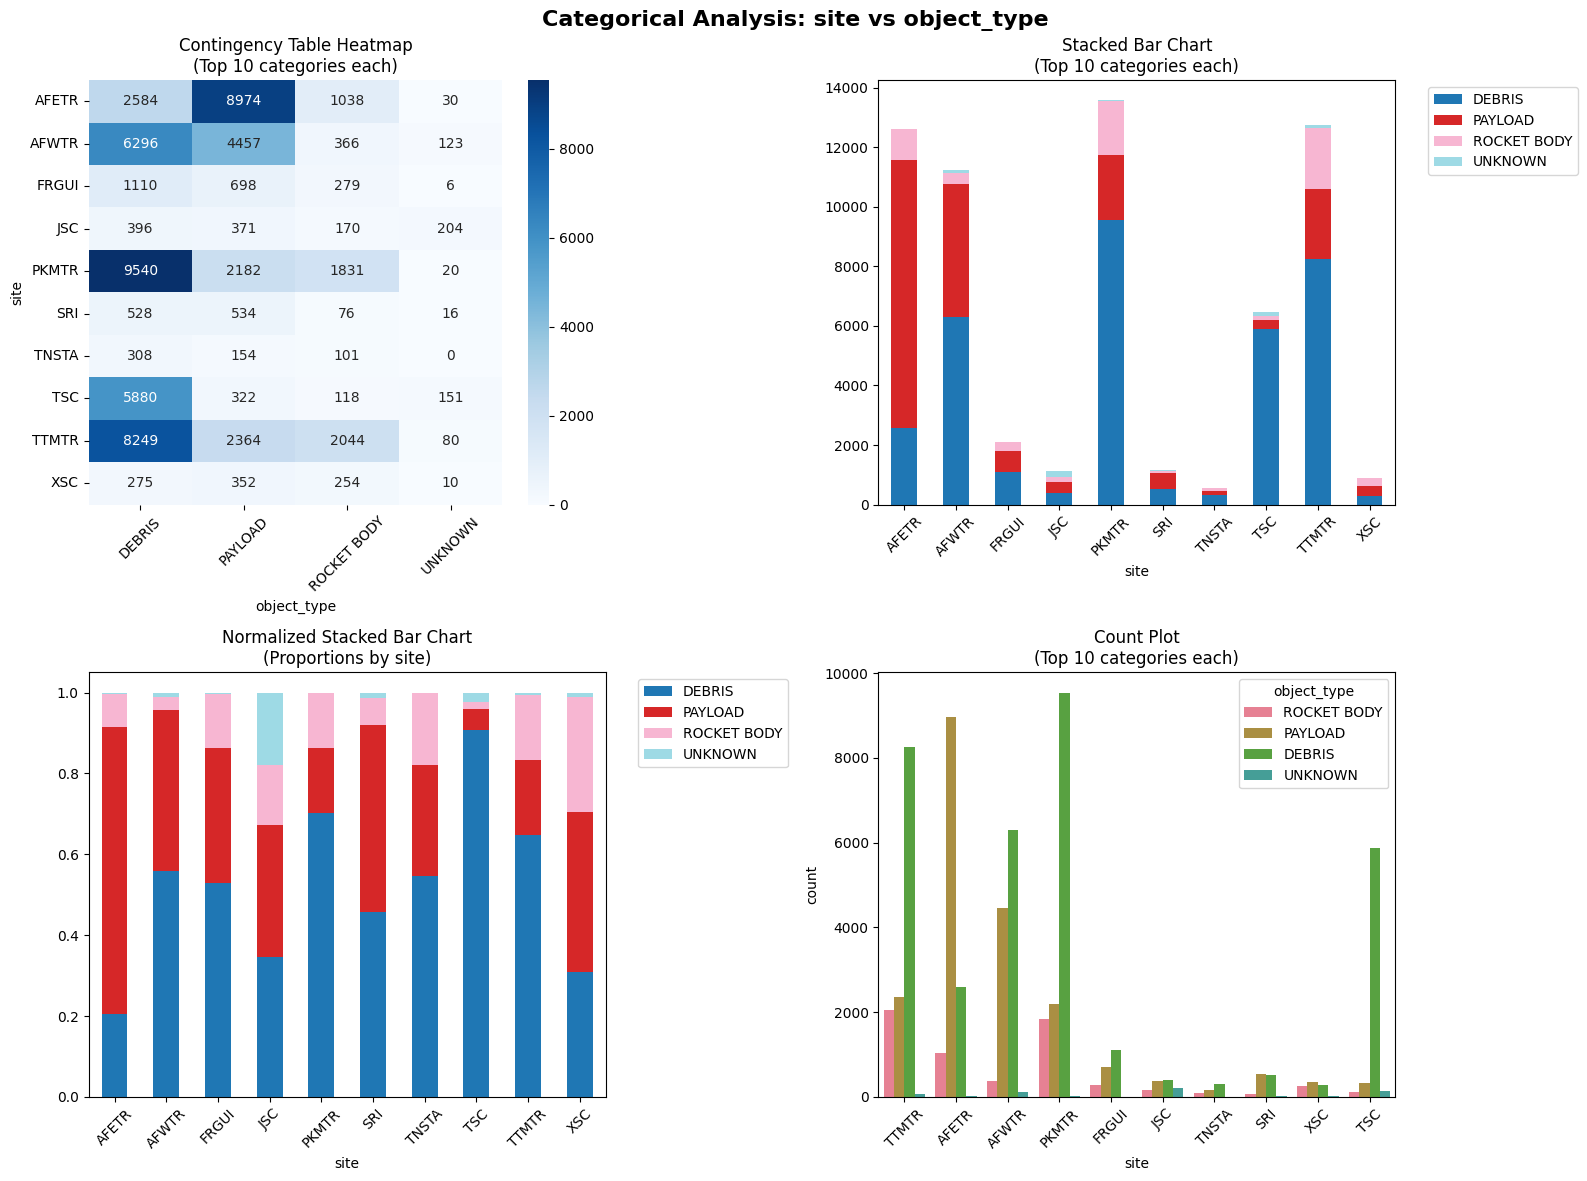


📋 SUMMARY:
   • Total observations: 65088
   • Valid observations: 65088
   • Most common site: PKMTR
   • Most common object_type: DEBRIS


In [89]:
# Inputs: satnav_tidy, analysis function | Process: site vs object_type analysis | Outputs: categorical analysis results
results = analyze_categorical_categorical(satnav_tidy, 'site', 'object_type')

🔍 CATEGORICAL-CATEGORICAL ANALYSIS: iso3 vs object_type

📊 BASIC INFORMATION:
   • Dataset shape: (65088, 36)
   • iso3 unique values: 99
   • object_type unique values: 4
   • Missing values in iso3: 0
   • Missing values in object_type: 0

📋 CONTINGENCY TABLE:
object_type  DEBRIS  PAYLOAD  ROCKET BODY  UNKNOWN  Total
iso3                                                     
AGO               0        2            0        0      2
ARE               0       25            0        0     25
ARG               1       68            0        0     69
AUS               0       61            2        0     63
AUT               0        4            0        0      4
...             ...      ...          ...      ...    ...
VEN               0        3            0        0      3
VNM               0        5            0        0      5
ZAF               0       11            0        0     11
ZWE               0        1            0        0      1
Total         35725    21695         6737

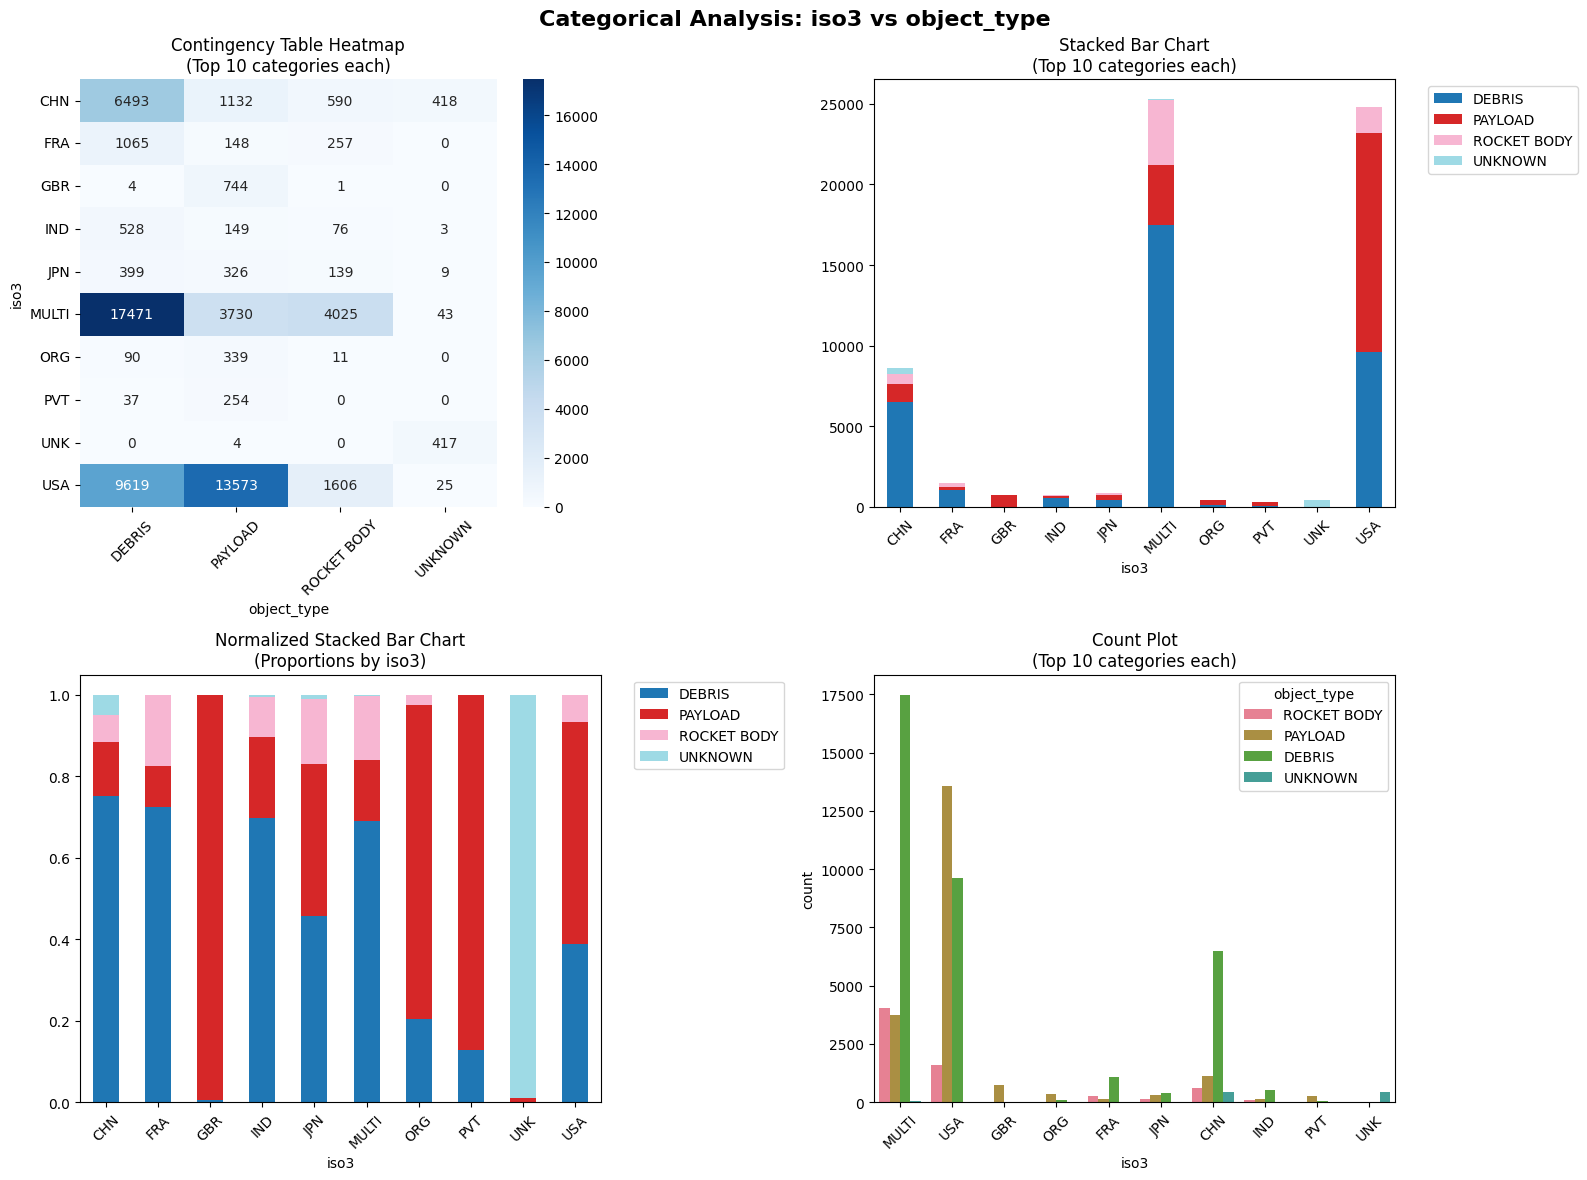


📋 SUMMARY:
   • Total observations: 65088
   • Valid observations: 65088
   • Most common iso3: MULTI
   • Most common object_type: DEBRIS


In [79]:
# Inputs: satnav_tidy, analysis function | Process: iso3 vs object_type analysis | Outputs: categorical analysis results
results = analyze_categorical_categorical(satnav_tidy, 'iso3', 'object_type')

In [ ]:
# Inputs: satnav_tidy | Process: Display data preview | Outputs: Interactive data table
show_freeze_header(satnav_tidy.head(500))

In [ ]:
# Inputs: satnav_tidy, analysis function | Process: COUNTRY vs object_type analysis | Outputs: categorical analysis results
results = analyze_categorical_categorical(satnav_tidy, 'COUNTRY', 'object_type')

In [ ]:
# Inputs: satnav_tidy, analysis function | Process: COUNTRY vs rcs_size analysis | Outputs: categorical analysis results
results = analyze_categorical_categorical(satnav_tidy, 'COUNTRY', 'rcs_size')

In [ ]:
# Inputs: satnav_tidy | Process: Display column names | Outputs: Column list
print(satnav_tidy.columns)


# Inputs: Analysis results | Process: Feature engineering planning | Outputs: Feature engineering roadmap

# Feature Engineering

Temporal Features: 
1. Satellite age
2. Launch Decade
3. Cold-war vs post-2000s
4. Launch density per year

Orbital Features: 
1. Altitude classification
2. Orbit type x Orbit regime - comms, navigation, EO/Spy sats, spent stages, fragmentation cloud

Perturbation features: 
1. Cumulative Revolution Index
2. Country ownership vs Orbital shell density
3. Launch site latitude vs inclination correlation

Visualization-ready Features: 
1. Launches by year and country - animated bar chart race (by year and decade)
2. Payloads vs Debris growth - stacked bar charts over time
3. LEO/MEO/GEO animated pie
4. Dynamic Pareto bar chart

In [ ]:
# Inputs: satnav_tidy, LAUNCH column | Process: Calculate object age in years and days | Outputs: object_age_years column, age statistics
# Calculate object age in years and days for better interpretation
from datetime import datetime

# Calculate age in years (more precise calculation)
satnav_tidy['object_age_years'] = (datetime.now() - pd.to_datetime(satnav_tidy['LAUNCH'])).dt.days / 365.25

# Display age statistics in both years and days
print("=== OBJECT AGE ANALYSIS ===")
print(f"\nAge Statistics (Days):")
print(f"  • Oldest object: {satnav_tidy['object_age'].max():.0f} days")
print(f"  • Youngest object: {satnav_tidy['object_age'].min():.0f} days")
print(f"  • Average age: {satnav_tidy['object_age'].mean():.0f} days")
print(f"  • Median age: {satnav_tidy['object_age'].median():.0f} days")

print(f"\nAge Statistics (Years):")
print(f"  • Oldest object: {satnav_tidy['object_age_years'].max():.1f} years")
print(f"  • Youngest object: {satnav_tidy['object_age_years'].min():.1f} years")
print(f"  • Average age: {satnav_tidy['object_age_years'].mean():.1f} years")
print(f"  • Median age: {satnav_tidy['object_age_years'].median():.1f} years")

# Show age distribution by object type
print(f"\nAge by Object Type (Years):")
age_by_type = satnav_tidy.groupby('object_type')['object_age_years'].agg(['mean', 'median', 'min', 'max']).round(1)
print(age_by_type)

# Show some interesting age milestones
print(f"\nAge Milestones:")
print(f"  • Objects older than 50 years: {len(satnav_tidy[satnav_tidy['object_age_years'] > 50])} ({len(satnav_tidy[satnav_tidy['object_age_years'] > 50])/len(satnav_tidy)*100:.1f}%)")
print(f"  • Objects older than 30 years: {len(satnav_tidy[satnav_tidy['object_age_years'] > 30])} ({len(satnav_tidy[satnav_tidy['object_age_years'] > 30])/len(satnav_tidy)*100:.1f}%)")
print(f"  • Objects older than 10 years: {len(satnav_tidy[satnav_tidy['object_age_years'] > 10])} ({len(satnav_tidy[satnav_tidy['object_age_years'] > 10])/len(satnav_tidy)*100:.1f}%)")
print(f"  • Objects younger than 1 year: {len(satnav_tidy[satnav_tidy['object_age_years'] < 1])} ({len(satnav_tidy[satnav_tidy['object_age_years'] < 1])/len(satnav_tidy)*100:.1f}%)")

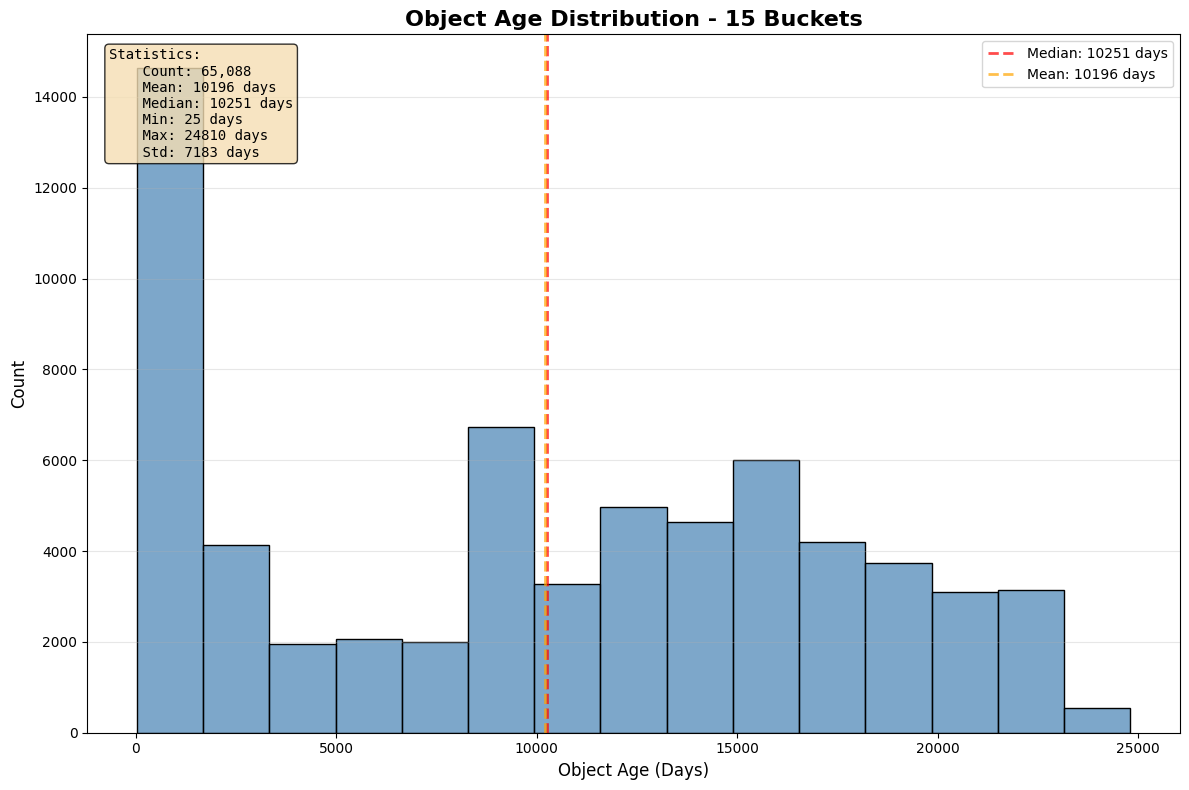

Object Age Distribution Analysis:
  Total objects: 65,088
  Age range: 25 - 24810 days
  Mean age: 10196 days (27.9 years)
  Median age: 10251 days (28.1 years)
  Standard deviation: 7183 days

Age by Object Type:
             Count  Mean_Age_Days  Median_Age_Days  Mean_Age_Years  \
object_type                                                          
DEBRIS       35725        12971.0          13324.0            35.5   
PAYLOAD      21695         5348.0           1598.0            14.6   
ROCKET BODY   6737        12327.0          13354.0            33.7   
UNKNOWN        931         1284.0            815.0             3.5   

             Median_Age_Years  
object_type                    
DEBRIS                   36.5  
PAYLOAD                   4.4  
ROCKET BODY              36.6  
UNKNOWN                   2.2  


In [80]:
# Inputs: satnav_tidy | Process: object age distribution | Outputs: histogram with 20 buckets
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Editable settings ---
# bins: number of histogram buckets
bins = 15

# log_scale: apply log scale to y-axis for skewed distributions
log_scale = False

# color: histogram color
hist_color = 'steelblue'
# -------------------------

# Ensure object_age column exists
if 'object_age' not in satnav_tidy.columns:
    from datetime import datetime
    satnav_tidy['object_age'] = (datetime.now() - pd.to_datetime(satnav_tidy['LAUNCH'])).dt.days

# Get age data (remove any NaN values)
age_data = satnav_tidy['object_age'].dropna()

if age_data.empty:
    print("No age data available to plot")
else:
    # Create the histogram
    plt.figure(figsize=(12, 8))
    
    # Create histogram with seaborn for better styling
    sns.histplot(age_data, bins=bins, kde=False, color=hist_color, edgecolor='black', alpha=0.7)
    
    # Customize the plot
    plt.title(f'Object Age Distribution - {bins} Buckets', fontsize=16, fontweight='bold')
    plt.xlabel('Object Age (Days)', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # Add grid for better readability
    plt.grid(True, axis='y', alpha=0.3)
    
    # Add statistics text box
    stats_text = f"""Statistics:
    Count: {len(age_data):,}
    Mean: {age_data.mean():.0f} days
    Median: {age_data.median():.0f} days
    Min: {age_data.min():.0f} days
    Max: {age_data.max():.0f} days
    Std: {age_data.std():.0f} days"""
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=10, fontfamily='monospace')
    
    # Apply log scale if requested
    if log_scale:
        plt.yscale('log')
        plt.title(f'Object Age Distribution - {bins} Buckets (Log Scale)', fontsize=16, fontweight='bold')
    
    # Add vertical lines for key percentiles
    plt.axvline(age_data.median(), color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Median: {age_data.median():.0f} days')
    plt.axvline(age_data.mean(), color='orange', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {age_data.mean():.0f} days')
    
    # Add legend
    plt.legend(loc='upper right')
    
    # Improve layout
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print(f"Object Age Distribution Analysis:")
    print(f"  Total objects: {len(age_data):,}")
    print(f"  Age range: {age_data.min():.0f} - {age_data.max():.0f} days")
    print(f"  Mean age: {age_data.mean():.0f} days ({age_data.mean()/365.25:.1f} years)")
    print(f"  Median age: {age_data.median():.0f} days ({age_data.median()/365.25:.1f} years)")
    print(f"  Standard deviation: {age_data.std():.0f} days")
    
    # Age distribution by object type
    print(f"\nAge by Object Type:")
    age_by_type = satnav_tidy.groupby('object_type')['object_age'].agg(['count', 'mean', 'median']).round(0)
    age_by_type.columns = ['Count', 'Mean_Age_Days', 'Median_Age_Days']
    age_by_type['Mean_Age_Years'] = (age_by_type['Mean_Age_Days'] / 365.25).round(1)
    age_by_type['Median_Age_Years'] = (age_by_type['Median_Age_Days'] / 365.25).round(1)
    print(age_by_type)

In [81]:
# Inputs: satnav_tidy, LAUNCH column | Process: Extract decade from launch date | Outputs: launch_decade, launch_decade_str columns
satnav_tidy['launch_decade'] = (pd.to_datetime(satnav_tidy['LAUNCH']).dt.year // 10) * 10
satnav_tidy['launch_decade_str'] = satnav_tidy['launch_decade'].astype(str) + 's'

In [82]:
# Inputs: satnav_tidy, LAUNCH column | Process: Create Cold War era encoder | Outputs: coldwar_to_ISS column
# Create Cold War encoder (one-liner version)
satnav_tidy['coldwar_to_ISS'] = satnav_tidy['LAUNCH'].apply(
    lambda x: 1 if pd.notna(x) and 1947 <= pd.to_datetime(x).year <= 1991
    else 3 if pd.notna(x) and pd.to_datetime(x).year >= 1998
    else 2 if pd.notna(x)
    else np.nan
)

In [83]:
# Inputs: satnav_tidy, coldwar_to_ISS column | Process: Validate Cold War encoder distribution | Outputs: Distribution statistics, sample data
# Check the distribution of Cold War categories
print("Cold War Era Distribution:")
print(satnav_tidy['coldwar_to_ISS'].value_counts().sort_index())
print("\nCold War Era Labels:")
print("1 = Cold War era (1947-1991)")
print("2 = Post-Cold War, Pre-ISS era (1992-1997)")  
print("3 = Post-ISS era (1998 onwards)")

# Show some examples
print("\nSample data with Cold War categories:")
sample_data = satnav_tidy[['SATNAME', 'LAUNCH', 'coldwar_to_ISS']].head(10)
print(sample_data)

Cold War Era Distribution:
coldwar_to_ISS
1    27365
2     6050
3    31673
Name: count, dtype: int64

Cold War Era Labels:
1 = Cold War era (1947-1991)
2 = Post-Cold War, Pre-ISS era (1992-1997)
3 = Post-ISS era (1998 onwards)

Sample data with Cold War categories:
      SATNAME      LAUNCH  coldwar_to_ISS
0    SL-1 R/B  1957-10-04               1
1   SPUTNIK 1  1957-10-04               1
2   SPUTNIK 2  1957-11-03               1
3  EXPLORER 1  1958-02-01               1
4  VANGUARD 1  1958-03-17               1
5  EXPLORER 3  1958-03-26               1
6    SL-1 R/B  1958-05-15               1
7   SPUTNIK 3  1958-05-15               1
8  EXPLORER 4  1958-07-26               1
9       SCORE  1958-12-18               1


In [84]:
# Inputs: satnav_tidy, periapsis, apoapsis columns | Process: Create robust altitude classification | Outputs: altitude_class, altitude_range_km, altitude_category, altitude_zone columns
# =============================================================================
# ROBUST ALTITUDE CLASSIFICATION SYSTEM
# =============================================================================
# This classification system is based on orbital mechanics, atmospheric effects,
# and practical space operations considerations.

def create_altitude_classification(df):
    """
    Create robust altitude classification based on orbital mechanics and space operations
    
    Classification Logic:
    1. VLEO (Very Low Earth Orbit): 0-200 km
       - Below Kármán line (100km) to 200km
       - High atmospheric drag, short orbital lifetime
       - Used for: Suborbital, early orbital, atmospheric research
    
    2. LEO (Low Earth Orbit): 200-2000 km  
       - Primary operational altitude range
       - Includes ISS altitude (400km), most satellites
       - Used for: Earth observation, communications, space stations
    
    3. MEO (Medium Earth Orbit): 2000-35786 km
       - Above LEO, below GEO
       - Includes GPS constellation altitude (~20,200km)
       - Used for: Navigation, some communications
    
    4. GEO (Geostationary Earth Orbit): 35786 km ± 200km
       - Synchronous with Earth's rotation
       - Critical altitude for geostationary satellites
       - Used for: Communications, weather, broadcasting
    
    5. HEO (High Earth Orbit): > 36000 km
       - Above geostationary altitude
       - Includes highly elliptical orbits
       - Used for: Deep space missions, some communications
    
    6. UNKNOWN: Missing or invalid altitude data
    """
    
    # Create a copy to avoid modifying original dataframe
    df_classified = df.copy()
    
    # Handle missing values and convert to numeric
    periapsis = pd.to_numeric(df_classified['periapsis'], errors='coerce')
    apoapsis = pd.to_numeric(df_classified['apoapsis'], errors='coerce')
    
    # Calculate average altitude for classification
    # Using periapsis as primary since it's more conservative for classification
    avg_altitude = periapsis.fillna(apoapsis)  # Use apoapsis if periapsis missing
    
    # Initialize altitude classification column
    df_classified['altitude_class'] = 'UNKNOWN'
    
    # Classification logic with clear boundaries
    # VLEO: 0-200 km (Very Low Earth Orbit)
    vleo_mask = (avg_altitude >= 0) & (avg_altitude < 200)
    df_classified.loc[vleo_mask, 'altitude_class'] = 'VLEO'
    
    # LEO: 200-2000 km (Low Earth Orbit) 
    leo_mask = (avg_altitude >= 200) & (avg_altitude < 2000)
    df_classified.loc[leo_mask, 'altitude_class'] = 'LEO'
    
    # MEO: 2000-35786 km (Medium Earth Orbit)
    meo_mask = (avg_altitude >= 2000) & (avg_altitude < 35786)
    df_classified.loc[meo_mask, 'altitude_class'] = 'MEO'
    
    # GEO: 35786 km ± 200km (Geostationary Earth Orbit)
    geo_mask = (avg_altitude >= 35586) & (avg_altitude <= 35986)
    df_classified.loc[geo_mask, 'altitude_class'] = 'GEO'
    
    # HEO: > 36000 km (High Earth Orbit)
    heo_mask = avg_altitude > 36000
    df_classified.loc[heo_mask, 'altitude_class'] = 'HEO'
    
    # Add additional classification columns for analysis
    # Altitude range (numeric for sorting/analysis)
    df_classified['altitude_range_km'] = avg_altitude
    
    # Altitude category (ordinal for statistical analysis)
    altitude_order = {'VLEO': 1, 'LEO': 2, 'MEO': 3, 'GEO': 4, 'HEO': 5, 'UNKNOWN': 0}
    df_classified['altitude_category'] = df_classified['altitude_class'].map(altitude_order)
    
    # Altitude zone (broader classification)
    df_classified['altitude_zone'] = df_classified['altitude_class'].replace({
        'VLEO': 'EARTH_ORBIT',
        'LEO': 'EARTH_ORBIT', 
        'MEO': 'EARTH_ORBIT',
        'GEO': 'GEOSTATIONARY',
        'HEO': 'DEEP_SPACE',
        'UNKNOWN': 'UNKNOWN'
    })
    
    return df_classified

# Apply the altitude classification
satnav_tidy = create_altitude_classification(satnav_tidy)

# =============================================================================
# VALIDATION AND ANALYSIS OF ALTITUDE CLASSIFICATION
# =============================================================================

# Display classification results
print("=== ALTITUDE CLASSIFICATION RESULTS ===")
print(f"Total objects classified: {len(satnav_tidy)}")
print(f"Objects with valid altitude data: {len(satnav_tidy[satnav_tidy['altitude_class'] != 'UNKNOWN'])}")
print(f"Objects with missing altitude data: {len(satnav_tidy[satnav_tidy['altitude_class'] == 'UNKNOWN'])}")

print("\n=== ALTITUDE CLASS DISTRIBUTION ===")
altitude_dist = satnav_tidy['altitude_class'].value_counts()
print(altitude_dist)

print("\n=== ALTITUDE CLASS PERCENTAGES ===")
altitude_pct = satnav_tidy['altitude_class'].value_counts(normalize=True) * 100
for class_name, percentage in altitude_pct.items():
    print(f"{class_name}: {percentage:.1f}%")

# Show altitude ranges for each class
print("\n=== ALTITUDE RANGES BY CLASS ===")
for class_name in ['VLEO', 'LEO', 'MEO', 'GEO', 'HEO']:
    class_data = satnav_tidy[satnav_tidy['altitude_class'] == class_name]['altitude_range_km']
    if len(class_data) > 0:
        print(f"{class_name}: {class_data.min():.0f} - {class_data.max():.0f} km (n={len(class_data)})")

# Cross-tabulation with object types
print("\n=== ALTITUDE CLASS BY OBJECT TYPE ===")
altitude_by_type = pd.crosstab(satnav_tidy['altitude_class'], satnav_tidy['object_type'], margins=True)
print(altitude_by_type)

=== ALTITUDE CLASSIFICATION RESULTS ===
Total objects classified: 65088
Objects with valid altitude data: 64108
Objects with missing altitude data: 980

=== ALTITUDE CLASS DISTRIBUTION ===
altitude_class
LEO        44224
VLEO       16602
MEO         1757
GEO         1011
UNKNOWN      980
HEO          514
Name: count, dtype: int64

=== ALTITUDE CLASS PERCENTAGES ===
LEO: 67.9%
VLEO: 25.5%
MEO: 2.7%
GEO: 1.6%
UNKNOWN: 1.5%
HEO: 0.8%

=== ALTITUDE RANGES BY CLASS ===
VLEO: 0 - 200 km (n=16602)
LEO: 200 - 1993 km (n=44224)
MEO: 2001 - 35586 km (n=1757)
GEO: 35587 - 35984 km (n=1011)
HEO: 36000 - 705392 km (n=514)

=== ALTITUDE CLASS BY OBJECT TYPE ===
object_type     DEBRIS  PAYLOAD  ROCKET BODY  UNKNOWN    All
altitude_class                                              
GEO                 31      873          107        0   1011
HEO                 15      423           76        0    514
LEO              26776    15095         1719      634  44224
MEO                698      587        

In [85]:
# Inputs: satnav_tidy, object_type, altitude_class columns | Process: Create mission type proxy classification | Outputs: mission_type, mission_complexity, mission_category columns
# =============================================================================
# MISSION TYPE PROXY CLASSIFICATION SYSTEM
# =============================================================================
# This classification system combines object_type and altitude_class to create
# meaningful mission type proxies based on space operations and orbital mechanics.

def create_mission_type_classification(df):
    """
    Create mission type proxy classification based on object_type × altitude_class
    
    Classification Logic:
    
    EARTH_OBSERVATION:
    - PAYLOAD in LEO: Primary Earth observation satellites
    - PAYLOAD in VLEO: High-resolution imaging, atmospheric research
    
    COMMUNICATIONS:
    - PAYLOAD in GEO: Geostationary communications satellites
    - PAYLOAD in MEO: Navigation constellations (GPS, Galileo)
    - PAYLOAD in HEO: Deep space communications, relay satellites
    
    SCIENTIFIC_RESEARCH:
    - PAYLOAD in MEO: Scientific missions, space weather monitoring
    - PAYLOAD in HEO: Deep space exploration, heliospheric missions
    - PAYLOAD in LEO: Space science, microgravity research
    
    MILITARY_SURVEILLANCE:
    - PAYLOAD in LEO: Reconnaissance, early warning systems
    - PAYLOAD in GEO: Strategic communications, missile warning
    
    SPACE_INFRASTRUCTURE:
    - PAYLOAD in LEO: Space stations, crew vehicles
    - ROCKET BODY in any orbit: Launch vehicle stages
    
    DEBRIS_MANAGEMENT:
    - DEBRIS in LEO: Space debris, collision fragments
    - DEBRIS in GEO: Geostationary debris, end-of-life satellites
    
    UNKNOWN_MISSION:
    - UNKNOWN object_type or missing data
    - Objects that don't fit standard mission profiles
    """
    
    # Create a copy to avoid modifying original dataframe
    df_classified = df.copy()
    
    # Initialize mission type column
    df_classified['mission_type'] = 'UNKNOWN_MISSION'
    
    # Ensure required columns exist
    if 'object_type' not in df_classified.columns or 'altitude_class' not in df_classified.columns:
        print("Warning: Required columns 'object_type' or 'altitude_class' not found")
        return df_classified
    
    # =============================================================================
    # MISSION TYPE CLASSIFICATION LOGIC
    # =============================================================================
    
    # EARTH_OBSERVATION: Payloads in LEO and VLEO
    earth_obs_mask = (
        (df_classified['object_type'] == 'PAYLOAD') & 
        (df_classified['altitude_class'].isin(['LEO', 'VLEO']))
    )
    df_classified.loc[earth_obs_mask, 'mission_type'] = 'EARTH_OBSERVATION'
    
    # COMMUNICATIONS: Payloads in GEO, MEO, and HEO
    comm_mask = (
        (df_classified['object_type'] == 'PAYLOAD') & 
        (df_classified['altitude_class'].isin(['GEO', 'MEO', 'HEO']))
    )
    df_classified.loc[comm_mask, 'mission_type'] = 'COMMUNICATIONS'
    
    # SCIENTIFIC_RESEARCH: Payloads in MEO, HEO, and some LEO
    scientific_mask = (
        (df_classified['object_type'] == 'PAYLOAD') & 
        (df_classified['altitude_class'].isin(['MEO', 'HEO']))
    )
    df_classified.loc[scientific_mask, 'mission_type'] = 'SCIENTIFIC_RESEARCH'
    
    # MILITARY_SURVEILLANCE: Payloads in LEO and GEO (strategic positions)
    military_mask = (
        (df_classified['object_type'] == 'PAYLOAD') & 
        (df_classified['altitude_class'].isin(['LEO', 'GEO']))
    )
    df_classified.loc[military_mask, 'mission_type'] = 'MILITARY_SURVEILLANCE'
    
    # SPACE_INFRASTRUCTURE: Space stations and launch vehicles
    infrastructure_mask = (
        (df_classified['object_type'] == 'PAYLOAD') & 
        (df_classified['altitude_class'] == 'LEO') &
        (df_classified['SATNAME'].str.contains('ISS|STATION|CREW|SHUTTLE', case=False, na=False))
    ) | (
        df_classified['object_type'] == 'ROCKET BODY'
    )
    df_classified.loc[infrastructure_mask, 'mission_type'] = 'SPACE_INFRASTRUCTURE'
    
    # DEBRIS_MANAGEMENT: All debris objects
    debris_mask = df_classified['object_type'] == 'DEBRIS'
    df_classified.loc[debris_mask, 'mission_type'] = 'DEBRIS_MANAGEMENT'
    
    # =============================================================================
    # REFINED CLASSIFICATION BASED ON ADDITIONAL CRITERIA
    # =============================================================================
    
    # Override some classifications based on satellite names and characteristics
    # Navigation satellites (GPS, Galileo, etc.)
    nav_mask = (
        (df_classified['mission_type'] == 'COMMUNICATIONS') &
        (df_classified['altitude_class'] == 'MEO') &
        (df_classified['SATNAME'].str.contains('GPS|GALILEO|GLONASS|BEIDOU|NAVSTAR', case=False, na=False))
    )
    df_classified.loc[nav_mask, 'mission_type'] = 'NAVIGATION'
    
    # Weather satellites
    weather_mask = (
        (df_classified['mission_type'] == 'EARTH_OBSERVATION') &
        (df_classified['SATNAME'].str.contains('WEATHER|METEOR|NOAA|GOES|METEOSAT', case=False, na=False))
    )
    df_classified.loc[weather_mask, 'mission_type'] = 'WEATHER_MONITORING'
    
    # Amateur radio and educational satellites
    amateur_mask = (
        (df_classified['object_type'] == 'PAYLOAD') &
        (df_classified['SATNAME'].str.contains('CUBESAT|AMATEUR|EDUCATIONAL|STUDENT', case=False, na=False))
    )
    df_classified.loc[amateur_mask, 'mission_type'] = 'EDUCATIONAL_AMATEUR'
    
    # =============================================================================
    # MISSION COMPLEXITY CLASSIFICATION
    # =============================================================================
    
    # Add mission complexity based on altitude and object type
    complexity_map = {
        'EARTH_OBSERVATION': 'MEDIUM',
        'COMMUNICATIONS': 'HIGH',
        'SCIENTIFIC_RESEARCH': 'HIGH',
        'MILITARY_SURVEILLANCE': 'HIGH',
        'SPACE_INFRASTRUCTURE': 'VERY_HIGH',
        'DEBRIS_MANAGEMENT': 'LOW',
        'NAVIGATION': 'VERY_HIGH',
        'WEATHER_MONITORING': 'MEDIUM',
        'EDUCATIONAL_AMATEUR': 'LOW',
        'UNKNOWN_MISSION': 'UNKNOWN'
    }
    
    df_classified['mission_complexity'] = df_classified['mission_type'].map(complexity_map)
    
    # =============================================================================
    # MISSION CATEGORY (BROADER CLASSIFICATION)
    # =============================================================================
    
    # Group mission types into broader categories
    category_map = {
        'EARTH_OBSERVATION': 'CIVILIAN',
        'COMMUNICATIONS': 'COMMERCIAL',
        'SCIENTIFIC_RESEARCH': 'SCIENTIFIC',
        'MILITARY_SURVEILLANCE': 'MILITARY',
        'SPACE_INFRASTRUCTURE': 'INFRASTRUCTURE',
        'DEBRIS_MANAGEMENT': 'WASTE',
        'NAVIGATION': 'INFRASTRUCTURE',
        'WEATHER_MONITORING': 'CIVILIAN',
        'EDUCATIONAL_AMATEUR': 'EDUCATIONAL',
        'UNKNOWN_MISSION': 'UNKNOWN'
    }
    
    df_classified['mission_category'] = df_classified['mission_type'].map(category_map)
    
    return df_classified

# Apply the mission type classification
satnav_tidy = create_mission_type_classification(satnav_tidy)

# =============================================================================
# VALIDATION AND ANALYSIS OF MISSION TYPE CLASSIFICATION
# =============================================================================

# Display classification results
print("=== MISSION TYPE CLASSIFICATION RESULTS ===")
print(f"Total objects classified: {len(satnav_tidy)}")
print(f"Objects with valid mission type: {len(satnav_tidy[satnav_tidy['mission_type'] != 'UNKNOWN_MISSION'])}")

print("\n=== MISSION TYPE DISTRIBUTION ===")
mission_dist = satnav_tidy['mission_type'].value_counts()
print(mission_dist)

print("\n=== MISSION TYPE PERCENTAGES ===")
mission_pct = satnav_tidy['mission_type'].value_counts(normalize=True) * 100
for mission_type, percentage in mission_pct.items():
    print(f"{mission_type}: {percentage:.1f}%")

# Cross-tabulation with object types
print("\n=== MISSION TYPE BY OBJECT TYPE ===")
mission_by_object = pd.crosstab(satnav_tidy['mission_type'], satnav_tidy['object_type'], margins=True)
print(mission_by_object)

# Cross-tabulation with altitude classes
print("\n=== MISSION TYPE BY ALTITUDE CLASS ===")
mission_by_altitude = pd.crosstab(satnav_tidy['mission_type'], satnav_tidy['altitude_class'], margins=True)
print(mission_by_altitude)

# Mission complexity distribution
print("\n=== MISSION COMPLEXITY DISTRIBUTION ===")
complexity_dist = satnav_tidy['mission_complexity'].value_counts()
print(complexity_dist)

# Mission category distribution
print("\n=== MISSION CATEGORY DISTRIBUTION ===")
category_dist = satnav_tidy['mission_category'].value_counts()
print(category_dist)

# Show some examples of each mission type
print("\n=== SAMPLE OBJECTS BY MISSION TYPE ===")
for mission_type in satnav_tidy['mission_type'].value_counts().head(5).index:
    sample = satnav_tidy[satnav_tidy['mission_type'] == mission_type][['SATNAME', 'object_type', 'altitude_class', 'mission_type']].head(3)
    print(f"\n{mission_type}:")
    print(sample.to_string(index=False))

=== MISSION TYPE CLASSIFICATION RESULTS ===
Total objects classified: 65088
Objects with valid mission type: 63738

=== MISSION TYPE DISTRIBUTION ===
mission_type
DEBRIS_MANAGEMENT        35725
MILITARY_SURVEILLANCE    15955
SPACE_INFRASTRUCTURE      6746
EARTH_OBSERVATION         4282
UNKNOWN_MISSION           1350
SCIENTIFIC_RESEARCH       1010
WEATHER_MONITORING          12
EDUCATIONAL_AMATEUR          8
Name: count, dtype: int64

=== MISSION TYPE PERCENTAGES ===
DEBRIS_MANAGEMENT: 54.9%
MILITARY_SURVEILLANCE: 24.5%
SPACE_INFRASTRUCTURE: 10.4%
EARTH_OBSERVATION: 6.6%
UNKNOWN_MISSION: 2.1%
SCIENTIFIC_RESEARCH: 1.6%
WEATHER_MONITORING: 0.0%
EDUCATIONAL_AMATEUR: 0.0%

=== MISSION TYPE BY OBJECT TYPE ===
object_type            DEBRIS  PAYLOAD  ROCKET BODY  UNKNOWN    All
mission_type                                                       
DEBRIS_MANAGEMENT       35725        0            0        0  35725
EARTH_OBSERVATION           0     4282            0        0   4282
EDUCATIONAL_AMA

KeyError: 'launches_per_year'

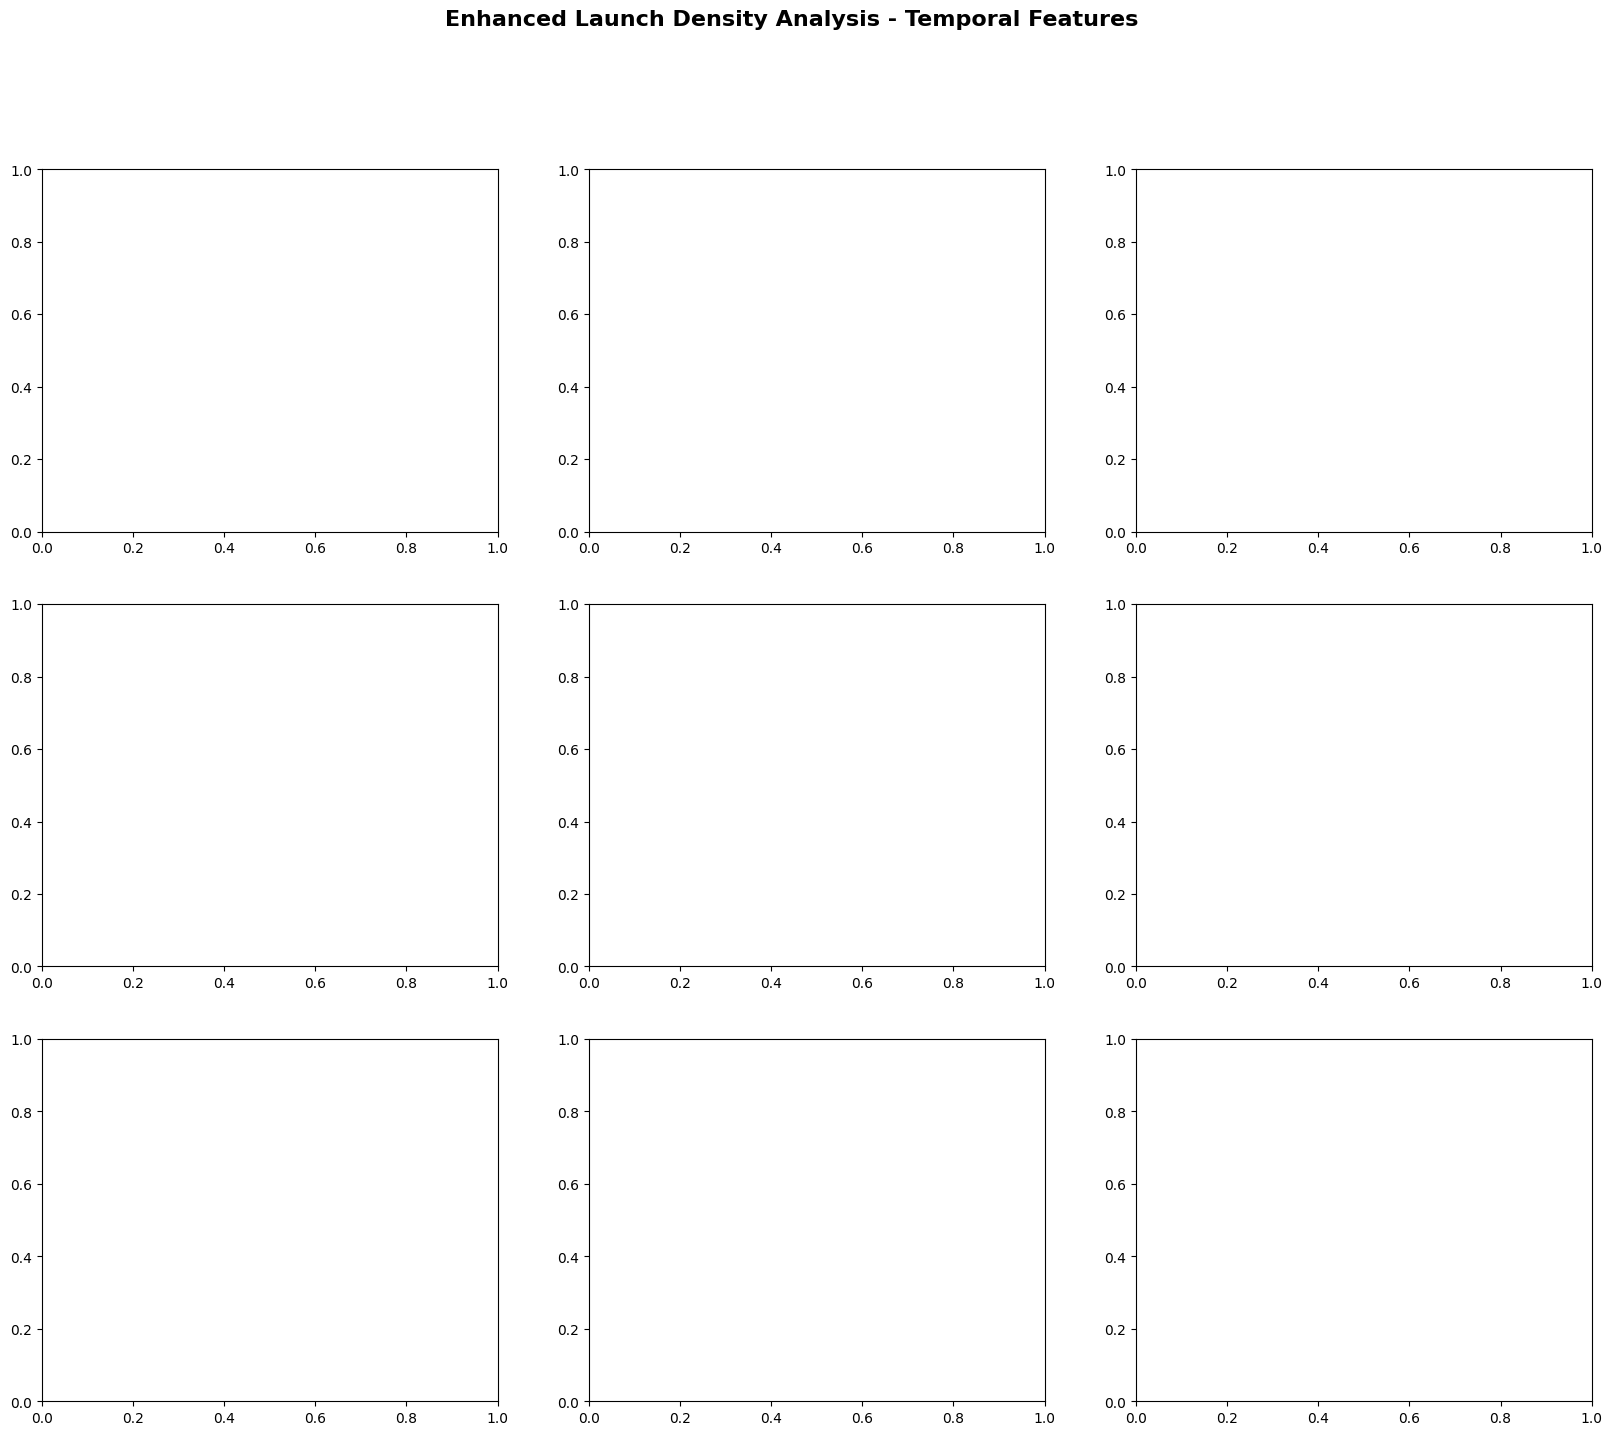

In [86]:
# Inputs: satnav_tidy, orbital and mission classifications | Process: Calculate enhanced launch density per year | Outputs: Comprehensive density metrics and visualizations
# =============================================================================
# ENHANCED TEMPORAL FEATURE CLASSIFICATION: LAUNCH DENSITY PER YEAR
# =============================================================================
# This system calculates launch density per year across multiple dimensions
# incorporating orbital classification and mission type classification.

def calculate_enhanced_launch_density(df):
    """
    Calculate comprehensive launch density per year with orbital and mission classifications
    
    Enhanced Parameters:
    1. Basic launch count per year
    2. Launch density by orbital classification (VLEO, LEO, MEO, GEO, HEO)
    3. Launch density by mission type (Earth Observation, Communications, etc.)
    4. Launch density by mission complexity (LOW, MEDIUM, HIGH, VERY_HIGH)
    5. Launch density by mission category (Civilian, Military, Commercial, etc.)
    6. Launch density by object type × orbital classification
    7. Launch density by country × orbital classification
    8. Launch density by launch site × mission type
    9. Orbital congestion density by altitude class
    10. Mission evolution density by decade
    """
    
    # Ensure required columns exist
    required_cols = ['LAUNCH_YEAR', 'altitude_class', 'mission_type', 'mission_complexity', 
                    'mission_category', 'object_type', 'COUNTRY', 'site', 'coldwar_true']
    
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
        return {}
    
    # =============================================================================
    # 1. BASIC LAUNCH DENSITY PER YEAR
    # =============================================================================
    
    # Total launches per year
    launches_per_year = df.groupby('LAUNCH_YEAR').size().reset_index(name='total_launches')
    
    # =============================================================================
    # 2. ORBITAL CLASSIFICATION DENSITY
    # =============================================================================
    
    # Launch density by orbital classification per year
    orbital_density = df.groupby(['LAUNCH_YEAR', 'altitude_class']).size().unstack(fill_value=0)
    
    # Orbital density percentages (normalized by year)
    orbital_density_pct = orbital_density.div(orbital_density.sum(axis=1), axis=0) * 100
    
    # =============================================================================
    # 3. MISSION TYPE DENSITY
    # =============================================================================
    
    # Launch density by mission type per year
    mission_density = df.groupby(['LAUNCH_YEAR', 'mission_type']).size().unstack(fill_value=0)
    
    # Mission density percentages
    mission_density_pct = mission_density.div(mission_density.sum(axis=1), axis=0) * 100
    
    # =============================================================================
    # 4. MISSION COMPLEXITY DENSITY
    # =============================================================================
    
    # Launch density by mission complexity per year
    complexity_density = df.groupby(['LAUNCH_YEAR', 'mission_complexity']).size().unstack(fill_value=0)
    
    # Complexity density percentages
    complexity_density_pct = complexity_density.div(complexity_density.sum(axis=1), axis=0) * 100
    
    # =============================================================================
    # 5. MISSION CATEGORY DENSITY
    # =============================================================================
    
    # Launch density by mission category per year
    category_density = df.groupby(['LAUNCH_YEAR', 'mission_category']).size().unstack(fill_value=0)
    
    # Category density percentages
    category_density_pct = category_density.div(category_density.sum(axis=1), axis=0) * 100
    
    # =============================================================================
    # 6. OBJECT TYPE × ORBITAL CLASSIFICATION DENSITY
    # =============================================================================
    
    # Cross-tabulation of object type and orbital classification
    object_orbital_density = df.groupby(['LAUNCH_YEAR', 'object_type', 'altitude_class']).size().unstack(fill_value=0)
    
    # =============================================================================
    # 7. COUNTRY × ORBITAL CLASSIFICATION DENSITY
    # =============================================================================
    
    # Top countries by total launches
    top_countries = df['COUNTRY'].value_counts().head(10).index
    
    # Country-orbital density for top countries
    country_orbital_density = df[df['COUNTRY'].isin(top_countries)].groupby(
        ['LAUNCH_YEAR', 'COUNTRY', 'altitude_class']
    ).size().unstack(fill_value=0)
    
    # =============================================================================
    # 8. LAUNCH SITE × MISSION TYPE DENSITY
    # =============================================================================
    
    # Top launch sites by total launches
    top_sites = df['site'].value_counts().head(10).index
    
    # Site-mission density for top sites
    site_mission_density = df[df['site'].isin(top_sites)].groupby(
        ['LAUNCH_YEAR', 'site', 'mission_type']
    ).size().unstack(fill_value=0)
    
    # =============================================================================
    # 9. ORBITAL CONGESTION DENSITY
    # =============================================================================
    
    # Calculate orbital congestion by altitude class
    orbital_congestion = {}
    for alt_class in ['VLEO', 'LEO', 'MEO', 'GEO', 'HEO']:
        class_data = df[df['altitude_class'] == alt_class]
        if len(class_data) > 0:
            orbital_congestion[alt_class] = class_data.groupby('LAUNCH_YEAR').size()
    
    # =============================================================================
    # 10. MISSION EVOLUTION DENSITY BY DECADE
    # =============================================================================
    
    # Mission evolution by decade
    mission_evolution = df.groupby(['launch_decade', 'mission_type']).size().unstack(fill_value=0)
    
    # =============================================================================
    # 11. HISTORICAL ERA DENSITY
    # =============================================================================
    
    # Launch density by historical era (Cold War classification)
    era_density = df.groupby(['LAUNCH_YEAR', 'coldwar_true']).size().unstack(fill_value=0)
    
    # =============================================================================
    # 12. WEIGHTED LAUNCH DENSITY
    # =============================================================================
    
    # Weight launches by mission complexity
    complexity_weights = {'LOW': 0.5, 'MEDIUM': 1.0, 'HIGH': 1.5, 'VERY_HIGH': 2.0, 'UNKNOWN': 0.5}
    df['complexity_weight'] = df['mission_complexity'].map(complexity_weights)
    
    # Weighted launch density per year
    weighted_density = df.groupby('LAUNCH_YEAR')['complexity_weight'].sum().reset_index(name='weighted_launches')
    
    # =============================================================================
    # 13. ORBITAL EFFICIENCY METRICS
    # =============================================================================
    
    # Calculate orbital efficiency (payloads vs debris ratio by altitude)
    orbital_efficiency = {}
    for alt_class in ['VLEO', 'LEO', 'MEO', 'GEO', 'HEO']:
        class_data = df[df['altitude_class'] == alt_class]
        if len(class_data) > 0:
            payloads = len(class_data[class_data['object_type'] == 'PAYLOAD'])
            debris = len(class_data[class_data['object_type'] == 'DEBRIS'])
            efficiency = payloads / (debris + 1) if debris > 0 else payloads
            orbital_efficiency[alt_class] = efficiency
    
    # =============================================================================
    # RETURN COMPREHENSIVE DENSITY METRICS
    # =============================================================================
    
    return {
        # Basic metrics
        'launches_per_year': launches_per_year,
        'weighted_density': weighted_density,
        
        # Orbital classification metrics
        'orbital_density': orbital_density,
        'orbital_density_pct': orbital_density_pct,
        'orbital_congestion': orbital_congestion,
        'orbital_efficiency': orbital_efficiency,
        
        # Mission classification metrics
        'mission_density': mission_density,
        'mission_density_pct': mission_density_pct,
        'complexity_density': complexity_density,
        'complexity_density_pct': complexity_density_pct,
        'category_density': category_density,
        'category_density_pct': category_density_pct,
        'mission_evolution': mission_evolution,
        
        # Cross-dimensional metrics
        'object_orbital_density': object_orbital_density,
        'country_orbital_density': country_orbital_density,
        'site_mission_density': site_mission_density,
        
        # Historical metrics
        'era_density': era_density
    }

# Calculate enhanced launch density metrics
density_metrics = calculate_enhanced_launch_density(satnav_tidy)

# =============================================================================
# COMPREHENSIVE VISUALIZATION OF ENHANCED LAUNCH DENSITY
# =============================================================================

def create_enhanced_density_visualizations(density_metrics):
    """Create comprehensive visualizations of launch density metrics"""
    
    # Create figure with multiple subplots
    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    fig.suptitle('Enhanced Launch Density Analysis - Temporal Features', fontsize=16, fontweight='bold')
    
    # 1. Total launches per year
    density_metrics['launches_per_year'].plot(x='LAUNCH_YEAR', y='total_launches', 
                                            kind='line', ax=axes[0,0], title='Total Launches per Year')
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Orbital density over time
    density_metrics['orbital_density'].plot(kind='area', stacked=True, ax=axes[0,1], 
                                          title='Launch Density by Orbital Classification')
    axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 3. Mission type density over time
    top_mission_types = density_metrics['mission_density'].sum().nlargest(5).index
    density_metrics['mission_density'][top_mission_types].plot(kind='line', ax=axes[0,2],
                                                              title='Top 5 Mission Types Over Time')
    axes[0,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 4. Mission complexity distribution
    density_metrics['complexity_density'].plot(kind='bar', stacked=True, ax=axes[1,0],
                                              title='Mission Complexity Distribution')
    axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 5. Mission category evolution
    density_metrics['category_density'].plot(kind='area', stacked=True, ax=axes[1,1],
                                            title='Mission Category Evolution')
    axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 6. Historical era density
    density_metrics['era_density'].plot(kind='bar', ax=axes[1,2],
                                       title='Launch Density by Historical Era')
    axes[1,2].legend(['Cold War', 'Transition', 'Modern'])
    
    # 7. Orbital efficiency by altitude class
    efficiency_data = pd.Series(density_metrics['orbital_efficiency'])
    efficiency_data.plot(kind='bar', ax=axes[2,0], title='Orbital Efficiency by Altitude Class')
    axes[2,0].set_ylabel('Payload/Debris Ratio')
    
    # 8. Weighted vs unweighted launches
    ax_twin = axes[2,1].twinx()
    density_metrics['launches_per_year'].plot(x='LAUNCH_YEAR', y='total_launches', 
                                            kind='line', ax=axes[2,1], color='blue', label='Total Launches')
    density_metrics['weighted_density'].plot(x='LAUNCH_YEAR', y='weighted_launches', 
                                           kind='line', ax=ax_twin, color='red', label='Weighted Launches')
    axes[2,1].set_title('Total vs Weighted Launch Density')
    axes[2,1].legend(loc='upper left')
    ax_twin.legend(loc='upper right')
    
    # 9. Mission evolution by decade
    density_metrics['mission_evolution'].plot(kind='bar', ax=axes[2,2],
                                             title='Mission Evolution by Decade')
    axes[2,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_enhanced_density_visualizations(density_metrics)

# =============================================================================
# SUMMARY STATISTICS AND INSIGHTS
# =============================================================================

print("=== ENHANCED LAUNCH DENSITY ANALYSIS SUMMARY ===")
print(f"Analysis period: {satnav_tidy['LAUNCH_YEAR'].min()} - {satnav_tidy['LAUNCH_YEAR'].max()}")
print(f"Total launches analyzed: {len(satnav_tidy):,}")

print("\n=== ORBITAL CLASSIFICATION INSIGHTS ===")
orbital_summary = density_metrics['orbital_density'].sum().sort_values(ascending=False)
for alt_class, count in orbital_summary.items():
    pct = (count / orbital_summary.sum()) * 100
    print(f"{alt_class}: {count:,} launches ({pct:.1f}%)")

print("\n=== MISSION TYPE INSIGHTS ===")
mission_summary = density_metrics['mission_density'].sum().sort_values(ascending=False)
for mission_type, count in mission_summary.head(5).items():
    pct = (count / mission_summary.sum()) * 100
    print(f"{mission_type}: {count:,} launches ({pct:.1f}%)")

print("\n=== MISSION COMPLEXITY INSIGHTS ===")
complexity_summary = density_metrics['complexity_density'].sum().sort_values(ascending=False)
for complexity, count in complexity_summary.items():
    pct = (count / complexity_summary.sum()) * 100
    print(f"{complexity}: {count:,} launches ({pct:.1f}%)")

print("\n=== HISTORICAL ERA INSIGHTS ===")
era_summary = density_metrics['era_density'].sum()
era_labels = {1: 'Cold War Era', 2: 'Transition Era', 3: 'Modern Era'}
for era_code, count in era_summary.items():
    pct = (count / era_summary.sum()) * 100
    print(f"{era_labels.get(era_code, 'Unknown')}: {count:,} launches ({pct:.1f}%)")

# Inputs: Density metrics | Process: Identify areas for improvement | Outputs: Improvement roadmap
# Needs improvement

In [ ]:


# Inputs: satnav_tidy, LAUNCH_YEAR, COUNTRY columns | Process: Import visualization libraries | Outputs: Library imports for animated visualization
# =============================================================================
# ANIMATED BAR RACE: LAUNCHES BY YEAR AND COUNTRY
# =============================================================================
# This creates an animated bar race chart showing the evolution of space launches
# by country over time, with dynamic labels and tracking of changes.

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from datetime import datetime


In [2]:
# Inputs: satnav_tidy, categorical column, numerical column | Process: Comprehensive categorical-numerical analysis | Outputs: Statistical tests, visualizations, summary statistics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal, mannwhitneyu
from scipy.stats import pointbiserialr
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

def analyze_categorical_numerical(df, cat_col, num_col, show_plots=True, plot_type='box', top_categories=10):
    """
    Comprehensive categorical-numerical analysis function
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data
    cat_col : str
        Column name for the categorical variable
    num_col : str
        Column name for the numerical variable
    show_plots : bool, default True
        Whether to display visualizations
    plot_type : str, default 'box'
        Type of visualization: 'box', 'violin', 'strip', 'histogram', 'all'
    top_categories : int, default 10
        Number of top categories to show in visualizations
    
    Returns:
    --------
    dict : Dictionary containing all analysis results
    """
    
    # Validate inputs
    if cat_col not in df.columns:
        raise ValueError(f"Column '{cat_col}' not found in dataframe")
    if num_col not in df.columns:
        raise ValueError(f"Column '{num_col}' not found in dataframe")
    
    print(f"🔍 CATEGORICAL-NUMERICAL ANALYSIS: {cat_col} vs {num_col}")
    print("=" * 60)
    
    # Remove missing values for analysis
    analysis_df = df[[cat_col, num_col]].dropna()
    
    # Basic information
    print(f"\n📊 BASIC INFORMATION:")
    print(f"   • Dataset shape: {df.shape}")
    print(f"   • Analysis dataset shape: {analysis_df.shape}")
    print(f"   • {cat_col} unique values: {analysis_df[cat_col].nunique()}")
    print(f"   • Missing values in {cat_col}: {df[cat_col].isna().sum()}")
    print(f"   • Missing values in {num_col}: {df[num_col].isna().sum()}")
    print(f"   • {num_col} data type: {analysis_df[num_col].dtype}")
    
    # =============================================================================
    # DESCRIPTIVE STATISTICS BY CATEGORY
    # =============================================================================
    
    print(f"\n📈 DESCRIPTIVE STATISTICS BY {cat_col.upper()}:")
    desc_stats = analysis_df.groupby(cat_col)[num_col].agg([
        'count', 'mean', 'median', 'std', 'min', 'max', 
        lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)
    ]).round(2)
    desc_stats.columns = ['Count', 'Mean', 'Median', 'Std', 'Min', 'Max', 'Q1', 'Q3']
    desc_stats['IQR'] = (desc_stats['Q3'] - desc_stats['Q1']).round(2)
    desc_stats['CV'] = (desc_stats['Std'] / desc_stats['Mean']).round(3)  # Coefficient of Variation
    
    print(desc_stats)
    
    # =============================================================================
    # STATISTICAL TESTS
    # =============================================================================
    
    print(f"\n🧪 STATISTICAL TESTS:")
    
    # Get groups for statistical testing
    groups = [group[num_col].values for name, group in analysis_df.groupby(cat_col) if len(group) > 1]
    
    if len(groups) < 2:
        print("   ⚠️  Cannot perform statistical tests: need at least 2 groups with data")
        anova_result = None
        kruskal_result = None
    else:
        # ANOVA (F-test) - assumes normality and equal variances
        try:
            f_stat, p_value_anova = f_oneway(*groups)
            print(f"   • ANOVA F-statistic: {f_stat:.4f}")
            print(f"   • ANOVA p-value: {p_value_anova:.6f}")
            print(f"   • ANOVA significance: {'***' if p_value_anova < 0.001 else '**' if p_value_anova < 0.01 else '*' if p_value_anova < 0.05 else 'ns'}")
            
            if p_value_anova < 0.05:
                print(f"   ✅ ANOVA Result: Significant differences between group means (p < 0.05)")
            else:
                print(f"   ❌ ANOVA Result: No significant differences between group means (p ≥ 0.05)")
                
            anova_result = {'f_statistic': f_stat, 'p_value': p_value_anova, 'significant': p_value_anova < 0.05}
        except Exception as e:
            print(f"   ⚠️  ANOVA failed: {e}")
            anova_result = None
        
        # Kruskal-Wallis test (non-parametric alternative)
        try:
            h_stat, p_value_kruskal = kruskal(*groups)
            print(f"   • Kruskal-Wallis H-statistic: {h_stat:.4f}")
            print(f"   • Kruskal-Wallis p-value: {p_value_kruskal:.6f}")
            print(f"   • Kruskal-Wallis significance: {'***' if p_value_kruskal < 0.001 else '**' if p_value_kruskal < 0.01 else '*' if p_value_kruskal < 0.05 else 'ns'}")
            
            if p_value_kruskal < 0.05:
                print(f"   ✅ Kruskal-Wallis Result: Significant differences between group distributions (p < 0.05)")
            else:
                print(f"   ❌ Kruskal-Wallis Result: No significant differences between group distributions (p ≥ 0.05)")
                
            kruskal_result = {'h_statistic': h_stat, 'p_value': p_value_kruskal, 'significant': p_value_kruskal < 0.05}
        except Exception as e:
            print(f"   ⚠️  Kruskal-Wallis test failed: {e}")
            kruskal_result = None
    
    # =============================================================================
    # EFFECT SIZE CALCULATIONS
    # =============================================================================
    
    print(f"\n📏 EFFECT SIZE MEASURES:")
    
    # Calculate eta-squared (effect size for ANOVA)
    if anova_result and anova_result['significant']:
        # Eta-squared = SS_between / SS_total
        total_var = analysis_df[num_col].var() * (len(analysis_df) - 1)
        between_var = 0
        grand_mean = analysis_df[num_col].mean()
        
        for name, group in analysis_df.groupby(cat_col):
            between_var += len(group) * (group[num_col].mean() - grand_mean) ** 2
        
        eta_squared = between_var / total_var
        print(f"   • Eta-squared (η²): {eta_squared:.4f}")
        print(f"   • Effect size interpretation: {'Large' if eta_squared > 0.14 else 'Medium' if eta_squared > 0.06 else 'Small'}")
    else:
        eta_squared = None
        print("   • Eta-squared: Not calculated (no significant ANOVA result)")
    
    # =============================================================================
    # VISUALIZATIONS
    # =============================================================================
    
    if show_plots:
        print(f"\n�� VISUALIZATIONS:")
        
        # Get top categories for cleaner visualizations
        top_cats = analysis_df[cat_col].value_counts().head(top_categories).index
        plot_df = analysis_df[analysis_df[cat_col].isin(top_cats)]
        
        if len(plot_df) > 0:
            # Create figure with subplots based on plot_type
            if plot_type == 'all':
                fig, axes = plt.subplots(2, 3, figsize=(18, 12))
                axes = axes.flatten()
            else:
                fig, axes = plt.subplots(1, 1, figsize=(12, 8))
                axes = [axes]
            
            fig.suptitle(f'Categorical-Numerical Analysis: {cat_col} vs {num_col}', fontsize=16, fontweight='bold')
            
            plot_idx = 0
            
            # 1. Box plots
            if plot_type in ['box', 'all']:
                sns.boxplot(data=plot_df, x=cat_col, y=num_col, ax=axes[plot_idx])
                axes[plot_idx].set_title(f'Box Plot by {cat_col}')
                axes[plot_idx].tick_params(axis='x', rotation=45)
                axes[plot_idx].grid(True, alpha=0.3)
                plot_idx += 1
            
            # 2. Violin plots
            if plot_type in ['violin', 'all']:
                sns.violinplot(data=plot_df, x=cat_col, y=num_col, ax=axes[plot_idx])
                axes[plot_idx].set_title(f'Violin Plot by {cat_col}')
                axes[plot_idx].tick_params(axis='x', rotation=45)
                axes[plot_idx].grid(True, alpha=0.3)
                plot_idx += 1
            
            # 3. Strip plots
            if plot_type in ['strip', 'all']:
                sns.stripplot(data=plot_df, x=cat_col, y=num_col, ax=axes[plot_idx], alpha=0.6, size=3)
                axes[plot_idx].set_title(f'Strip Plot by {cat_col}')
                axes[plot_idx].tick_params(axis='x', rotation=45)
                axes[plot_idx].grid(True, alpha=0.3)
                plot_idx += 1
            
            # 4. Histogram overlays
            if plot_type in ['histogram', 'all']:
                for cat in top_cats[:5]:  # Limit to top 5 for readability
                    cat_data = plot_df[plot_df[cat_col] == cat][num_col]
                    axes[plot_idx].hist(cat_data, alpha=0.6, label=cat, bins=20)
                axes[plot_idx].set_title(f'Histogram Overlay by {cat_col}')
                axes[plot_idx].set_xlabel(num_col)
                axes[plot_idx].set_ylabel('Frequency')
                axes[plot_idx].legend()
                axes[plot_idx].grid(True, alpha=0.3)
                plot_idx += 1
            
            # 5. Mean comparison bar chart
            if plot_type in ['all']:
                means = plot_df.groupby(cat_col)[num_col].mean().sort_values(ascending=False)
                means.plot(kind='bar', ax=axes[plot_idx], color='steelblue', alpha=0.7)
                axes[plot_idx].set_title(f'Mean {num_col} by {cat_col}')
                axes[plot_idx].tick_params(axis='x', rotation=45)
                axes[plot_idx].grid(True, alpha=0.3)
                axes[plot_idx].set_ylabel(f'Mean {num_col}')
                plot_idx += 1
            
            # 6. Statistical summary
            if plot_type in ['all']:
                # Create a text summary
                summary_text = f"""Statistical Summary:
                
ANOVA: {'Significant' if anova_result and anova_result['significant'] else 'Not Significant'}
Kruskal-Wallis: {'Significant' if kruskal_result and kruskal_result['significant'] else 'Not Significant'}
Effect Size (η²): {eta_squared:.4f if eta_squared else 'N/A'}

Top Categories by Mean:
{desc_stats.sort_values('Mean', ascending=False).head(3)[['Mean', 'Count']].to_string()}"""
                
                axes[plot_idx].text(0.1, 0.9, summary_text, transform=axes[plot_idx].transAxes, 
                                  verticalalignment='top', fontsize=10, fontfamily='monospace',
                                  bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
                axes[plot_idx].set_title('Statistical Summary')
                axes[plot_idx].axis('off')
            
            # Hide unused subplots
            for i in range(plot_idx, len(axes)):
                axes[i].set_visible(False)
            
            plt.tight_layout()
            plt.show()
        else:
            print("   ⚠️  No data available for visualization after filtering")
    
    # =============================================================================
    # SUMMARY STATISTICS
    # =============================================================================
    
    print(f"\n📋 SUMMARY:")
    print(f"   • Total observations: {len(df)}")
    print(f"   • Valid observations: {len(analysis_df)}")
    print(f"   • Most common {cat_col}: {analysis_df[cat_col].mode().iloc[0] if not analysis_df[cat_col].mode().empty else 'N/A'}")
    print(f"   • {num_col} range: {analysis_df[num_col].min():.2f} - {analysis_df[num_col].max():.2f}")
    print(f"   • {num_col} overall mean: {analysis_df[num_col].mean():.2f}")
    print(f"   • {num_col} overall median: {analysis_df[num_col].median():.2f}")
    
    # =============================================================================
    # RETURN RESULTS DICTIONARY
    # =============================================================================
    
    results = {
        'descriptive_stats': desc_stats,
        'anova_result': anova_result,
        'kruskal_result': kruskal_result,
        'eta_squared': eta_squared,
        'analysis_df': analysis_df,
        'top_categories': top_cats.tolist(),
        'overall_stats': {
            'mean': analysis_df[num_col].mean(),
            'median': analysis_df[num_col].median(),
            'std': analysis_df[num_col].std(),
            'min': analysis_df[num_col].min(),
            'max': analysis_df[num_col].max()
        }
    }
    
    return results

# Example usage and test the function
print("🚀 CATEGORICAL-NUMERICAL ANALYSIS FUNCTION READY!")
print("\nExample usage:")
print("results = analyze_categorical_numerical(satnav_tidy, 'object_type', 'object_age')")
print("results = analyze_categorical_numerical(satnav_tidy, 'COUNTRY', 'periapsis', plot_type='violin')")
print("results = analyze_categorical_numerical(satnav_tidy, 'altitude_class', 'object_age', plot_type='all')")

🚀 CATEGORICAL-NUMERICAL ANALYSIS FUNCTION READY!

Example usage:
results = analyze_categorical_numerical(satnav_tidy, 'object_type', 'object_age')
results = analyze_categorical_numerical(satnav_tidy, 'COUNTRY', 'periapsis', plot_type='violin')
results = analyze_categorical_numerical(satnav_tidy, 'altitude_class', 'object_age', plot_type='all')


🔍 CATEGORICAL-NUMERICAL ANALYSIS: iso3 vs LAUNCH_YEAR

📊 BASIC INFORMATION:
   • Dataset shape: (65088, 36)
   • Analysis dataset shape: (65088, 2)
   • iso3 unique values: 99
   • Missing values in iso3: 0
   • Missing values in LAUNCH_YEAR: 0
   • LAUNCH_YEAR data type: int64

📈 DESCRIPTIVE STATISTICS BY ISO3:
      Count     Mean  Median    Std   Min   Max       Q1       Q3   IQR     CV
iso3                                                                          
AGO       2  2019.50  2019.5   3.54  2017  2022  2018.25  2020.75   2.5  0.002
ARE      25  2016.60  2020.0   7.85  1998  2025  2012.00  2022.00  10.0  0.004
ARG      69  2016.84  2020.0   9.55  1983  2025  2016.00  2023.00   7.0  0.005
AUS      63  2011.21  2018.0  14.78  1967  2025  1998.00  2023.00  25.0  0.007
AUT       4  2016.50  2015.0   4.73  2013  2023  2013.00  2018.50   5.5  0.002
...     ...      ...     ...    ...   ...   ...      ...      ...   ...    ...
USA   24823  2002.24  2014.0  22.77  1958  2025  1978.

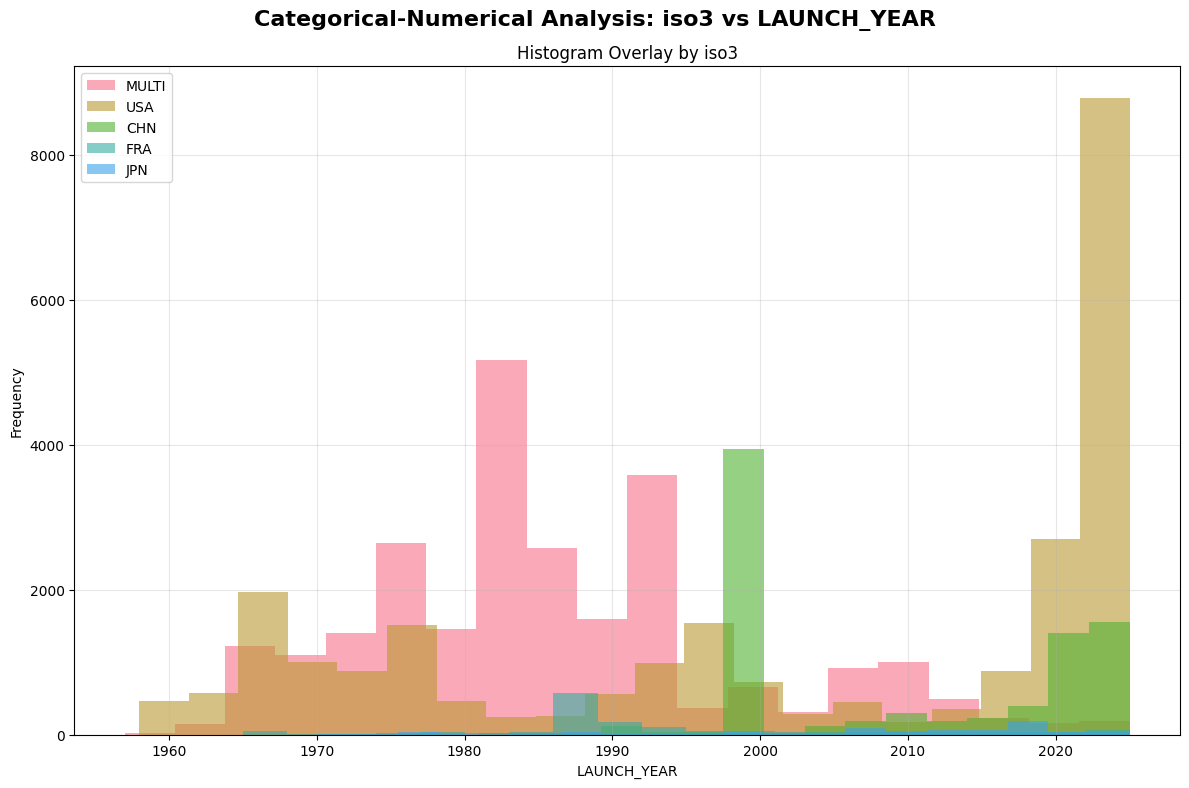


📋 SUMMARY:
   • Total observations: 65088
   • Valid observations: 65088
   • Most common iso3: MULTI
   • LAUNCH_YEAR range: 1957.00 - 2025.00
   • LAUNCH_YEAR overall mean: 1997.25
   • LAUNCH_YEAR overall median: 1997.00


In [8]:
results = analyze_categorical_numerical(satnav_tidy, 'iso3', 'LAUNCH_YEAR', plot_type='histogram')


In [9]:
# Inputs: satnav_tidy, numerical column 1, numerical column 2 | Process: Comprehensive numerical-numerical analysis | Outputs: Statistical tests, visualizations, regression analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

def analyze_numerical_numerical(df, num_col1, num_col2, show_plots=True, plot_type='scatter', 
                               regression_type='linear', max_points=10000, n_clusters=3):
    """
    Comprehensive numerical-numerical analysis function
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the data
    num_col1, num_col2 : str
        Column names for the two numerical variables
    show_plots : bool, default True
        Whether to display visualizations
    plot_type : str, default 'scatter'
        Type of visualization: 'scatter', 'hexbin', 'joint', 'all'
    regression_type : str, default 'linear'
        Type of regression: 'linear', 'polynomial', 'both'
    max_points : int, default 10000
        Maximum number of points to plot (for performance)
    n_clusters : int, default 3
        Number of clusters for K-means clustering
    
    Returns:
    --------
    dict : Dictionary containing all analysis results
    """
    
    # Validate inputs
    if num_col1 not in df.columns:
        raise ValueError(f"Column '{num_col1}' not found in dataframe")
    if num_col2 not in df.columns:
        raise ValueError(f"Column '{num_col2}' not found in dataframe")
    
    print(f"🔍 NUMERICAL-NUMERICAL ANALYSIS: {num_col1} vs {num_col2}")
    print("=" * 60)
    
    # Remove missing values for analysis
    analysis_df = df[[num_col1, num_col2]].dropna()
    
    # Sample data if too large for plotting
    plot_df = analysis_df
    if len(analysis_df) > max_points:
        plot_df = analysis_df.sample(n=max_points, random_state=42)
        print(f"   ⚠️  Dataset large ({len(analysis_df):,} points), sampling {max_points:,} for visualization")
    
    # Basic information
    print(f"\n📊 BASIC INFORMATION:")
    print(f"   • Dataset shape: {df.shape}")
    print(f"   • Analysis dataset shape: {analysis_df.shape}")
    print(f"   • Plotting dataset shape: {plot_df.shape}")
    print(f"   • Missing values in {num_col1}: {df[num_col1].isna().sum()}")
    print(f"   • Missing values in {num_col2}: {df[num_col2].isna().sum()}")
    print(f"   • {num_col1} data type: {analysis_df[num_col1].dtype}")
    print(f"   • {num_col2} data type: {analysis_df[num_col2].dtype}")
    
    # =============================================================================
    # DESCRIPTIVE STATISTICS
    # =============================================================================
    
    print(f"\n📈 DESCRIPTIVE STATISTICS:")
    desc_stats = analysis_df[[num_col1, num_col2]].describe().round(3)
    print(desc_stats)
    
    # Additional statistics
    print(f"\n�� ADDITIONAL STATISTICS:")
    for col in [num_col1, num_col2]:
        col_data = analysis_df[col]
        print(f"   {col}:")
        print(f"     • Skewness: {stats.skew(col_data):.3f}")
        print(f"     • Kurtosis: {stats.kurtosis(col_data):.3f}")
        print(f"     • Coefficient of Variation: {(col_data.std() / col_data.mean()):.3f}")
    
    # =============================================================================
    # CORRELATION ANALYSIS
    # =============================================================================
    
    print(f"\n🔗 CORRELATION ANALYSIS:")
    
    # Pearson correlation (linear relationship)
    pearson_corr, pearson_p = pearsonr(analysis_df[num_col1], analysis_df[num_col2])
    print(f"   • Pearson correlation: {pearson_corr:.4f}")
    print(f"   • Pearson p-value: {pearson_p:.6f}")
    print(f"   • Pearson significance: {'***' if pearson_p < 0.001 else '**' if pearson_p < 0.01 else '*' if pearson_p < 0.05 else 'ns'}")
    
    # Spearman correlation (monotonic relationship)
    spearman_corr, spearman_p = spearmanr(analysis_df[num_col1], analysis_df[num_col2])
    print(f"   • Spearman correlation: {spearman_corr:.4f}")
    print(f"   • Spearman p-value: {spearman_p:.6f}")
    print(f"   • Spearman significance: {'***' if spearman_p < 0.001 else '**' if spearman_p < 0.01 else '*' if spearman_p < 0.05 else 'ns'}")
    
    # Correlation interpretation
    def interpret_correlation(corr):
        abs_corr = abs(corr)
        if abs_corr >= 0.9:
            return "Very Strong"
        elif abs_corr >= 0.7:
            return "Strong"
        elif abs_corr >= 0.5:
            return "Moderate"
        elif abs_corr >= 0.3:
            return "Weak"
        else:
            return "Very Weak"
    
    print(f"   • Pearson relationship strength: {interpret_correlation(pearson_corr)}")
    print(f"   • Spearman relationship strength: {interpret_correlation(spearman_corr)}")
    
    # =============================================================================
    # REGRESSION ANALYSIS
    # =============================================================================
    
    print(f"\n📊 REGRESSION ANALYSIS:")
    
    # Prepare data for regression
    X = analysis_df[[num_col1]].values
    y = analysis_df[num_col2].values
    
    regression_results = {}
    
    # Linear regression
    if regression_type in ['linear', 'both']:
        linear_model = LinearRegression()
        linear_model.fit(X, y)
        y_pred_linear = linear_model.predict(X)
        r2_linear = r2_score(y, y_pred_linear)
        
        print(f"   📈 LINEAR REGRESSION:")
        print(f"     • R²: {r2_linear:.4f}")
        print(f"     • Slope: {linear_model.coef_[0]:.4f}")
        print(f"     • Intercept: {linear_model.intercept_:.4f}")
        print(f"     • Equation: y = {linear_model.coef_[0]:.4f}x + {linear_model.intercept_:.4f}")
        
        regression_results['linear'] = {
            'model': linear_model,
            'r2': r2_linear,
            'slope': linear_model.coef_[0],
            'intercept': linear_model.intercept_,
            'predictions': y_pred_linear
        }
    
    # Polynomial regression
    if regression_type in ['polynomial', 'both']:
        poly_features = PolynomialFeatures(degree=2)
        X_poly = poly_features.fit_transform(X)
        poly_model = LinearRegression()
        poly_model.fit(X_poly, y)
        y_pred_poly = poly_model.predict(X_poly)
        r2_poly = r2_score(y, y_pred_poly)
        
        print(f"   📈 POLYNOMIAL REGRESSION (degree=2):")
        print(f"     • R²: {r2_poly:.4f}")
        print(f"     • Coefficients: {poly_model.coef_}")
        print(f"     • Intercept: {poly_model.intercept_:.4f}")
        
        regression_results['polynomial'] = {
            'model': poly_model,
            'poly_features': poly_features,
            'r2': r2_poly,
            'coefficients': poly_model.coef_,
            'intercept': poly_model.intercept_,
            'predictions': y_pred_poly
        }
    
    # =============================================================================
    # OUTLIER DETECTION
    # =============================================================================
    
    print(f"\n🎯 OUTLIER DETECTION:")
    
    # IQR method
    def detect_outliers_iqr(data):
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return (data < lower_bound) | (data > upper_bound)
    
    outliers_col1 = detect_outliers_iqr(analysis_df[num_col1])
    outliers_col2 = detect_outliers_iqr(analysis_df[num_col2])
    outliers_both = outliers_col1 | outliers_col2
    
    print(f"   • Outliers in {num_col1}: {outliers_col1.sum()} ({outliers_col1.sum()/len(analysis_df)*100:.1f}%)")
    print(f"   • Outliers in {num_col2}: {outliers_col2.sum()} ({outliers_col2.sum()/len(analysis_df)*100:.1f}%)")
    print(f"   • Outliers in either variable: {outliers_both.sum()} ({outliers_both.sum()/len(analysis_df)*100:.1f}%)")
    
    # =============================================================================
    # CLUSTERING ANALYSIS
    # =============================================================================
    
    print(f"\n🎯 CLUSTERING ANALYSIS:")
    
    try:
        # Standardize data for clustering
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(analysis_df[[num_col1, num_col2]])
        
        # K-means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        clusters = kmeans.fit_predict(X_scaled)
        
        # Add clusters to dataframe
        analysis_df_clustered = analysis_df.copy()
        analysis_df_clustered['cluster'] = clusters
        
        print(f"   • K-means clustering with {n_clusters} clusters:")
        cluster_summary = analysis_df_clustered.groupby('cluster')[[num_col1, num_col2]].agg(['count', 'mean', 'std']).round(3)
        print(cluster_summary)
        
        clustering_results = {
            'model': kmeans,
            'scaler': scaler,
            'clusters': clusters,
            'cluster_summary': cluster_summary
        }
    except Exception as e:
        print(f"   ⚠️  Clustering failed: {e}")
        clustering_results = None
    
    # =============================================================================
    # VISUALIZATIONS
    # =============================================================================
    
    if show_plots:
        print(f"\n VISUALIZATIONS:")
        
        # Create figure with subplots based on plot_type
        if plot_type == 'all':
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            axes = axes.flatten()
        else:
            fig, axes = plt.subplots(1, 1, figsize=(10, 8))
            axes = [axes]
        
        fig.suptitle(f'Numerical-Numerical Analysis: {num_col1} vs {num_col2}', fontsize=16, fontweight='bold')
        
        plot_idx = 0
        
        # 1. Scatter plot with trend line
        if plot_type in ['scatter', 'all']:
            ax = axes[plot_idx]
            ax.scatter(plot_df[num_col1], plot_df[num_col2], alpha=0.6, s=20, color='steelblue')
            
            # Add regression line
            if regression_type in ['linear', 'both'] and 'linear' in regression_results:
                x_range = np.linspace(plot_df[num_col1].min(), plot_df[num_col1].max(), 100)
                y_pred = regression_results['linear']['model'].predict(x_range.reshape(-1, 1))
                ax.plot(x_range, y_pred, color='red', linewidth=2, label=f'Linear (R²={regression_results["linear"]["r2"]:.3f})')
            
            if regression_type in ['polynomial', 'both'] and 'polynomial' in regression_results:
                x_range = np.linspace(plot_df[num_col1].min(), plot_df[num_col1].max(), 100)
                x_range_poly = regression_results['polynomial']['poly_features'].transform(x_range.reshape(-1, 1))
                y_pred_poly = regression_results['polynomial']['model'].predict(x_range_poly)
                ax.plot(x_range, y_pred_poly, color='green', linewidth=2, label=f'Polynomial (R²={regression_results["polynomial"]["r2"]:.3f})')
            
            ax.set_xlabel(num_col1)
            ax.set_ylabel(num_col2)
            ax.set_title(f'Scatter Plot with Regression Lines')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plot_idx += 1
        
        # 2. Hexbin plot
        if plot_type in ['hexbin', 'all']:
            ax = axes[plot_idx]
            hb = ax.hexbin(plot_df[num_col1], plot_df[num_col2], gridsize=30, cmap='Blues', alpha=0.8)
            ax.set_xlabel(num_col1)
            ax.set_ylabel(num_col2)
            ax.set_title(f'Hexbin Plot (Density)')
            plt.colorbar(hb, ax=ax, label='Count')
            plot_idx += 1
        
        # 3. Joint plot
        if plot_type in ['joint', 'all']:
            ax = axes[plot_idx]
            # Create joint plot manually
            g = sns.jointplot(data=plot_df, x=num_col1, y=num_col2, kind='scatter', alpha=0.6, ax=ax)
            g.ax_joint.set_xlabel(num_col1)
            g.ax_joint.set_ylabel(num_col2)
            g.ax_joint.set_title(f'Joint Plot with Marginal Distributions')
            plot_idx += 1
        
        # 4. Correlation heatmap
        if plot_type in ['all']:
            ax = axes[plot_idx]
            corr_matrix = analysis_df[[num_col1, num_col2]].corr()
            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, square=True)
            ax.set_title(f'Correlation Heatmap')
            plot_idx += 1
        
        # 5. Residual plot
        if plot_type in ['all'] and 'linear' in regression_results:
            ax = axes[plot_idx]
            residuals = analysis_df[num_col2] - regression_results['linear']['predictions']
            ax.scatter(regression_results['linear']['predictions'], residuals, alpha=0.6, color='steelblue')
            ax.axhline(y=0, color='red', linestyle='--')
            ax.set_xlabel('Predicted Values')
            ax.set_ylabel('Residuals')
            ax.set_title(f'Residual Plot (Linear Regression)')
            ax.grid(True, alpha=0.3)
            plot_idx += 1
        
        # 6. Clustering plot
        if plot_type in ['all'] and clustering_results is not None:
            ax = axes[plot_idx]
            scatter = ax.scatter(plot_df[num_col1], plot_df[num_col2], c=clusters[:len(plot_df)], cmap='viridis', alpha=0.6)
            ax.set_xlabel(num_col1)
            ax.set_ylabel(num_col2)
            ax.set_title(f'K-means Clustering ({n_clusters} clusters)')
            plt.colorbar(scatter, ax=ax, label='Cluster')
            plot_idx += 1
        
        # Hide unused subplots
        for i in range(plot_idx, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
    
    # =============================================================================
    # SUMMARY STATISTICS
    # =============================================================================
    
    print(f"\n📋 SUMMARY:")
    print(f"   • Total observations: {len(df)}")
    print(f"   • Valid observations: {len(analysis_df)}")
    print(f"   • {num_col1} range: {analysis_df[num_col1].min():.2f} - {analysis_df[num_col1].max():.2f}")
    print(f"   • {num_col2} range: {analysis_df[num_col2].min():.2f} - {analysis_df[num_col2].max():.2f}")
    print(f"   • Pearson correlation: {pearson_corr:.4f} ({interpret_correlation(pearson_corr)})")
    print(f"   • Spearman correlation: {spearman_corr:.4f} ({interpret_correlation(spearman_corr)})")
    
    # =============================================================================
    # RETURN RESULTS DICTIONARY
    # =============================================================================
    
    results = {
        'descriptive_stats': desc_stats,
        'correlation_results': {
            'pearson': {'correlation': pearson_corr, 'p_value': pearson_p, 'significant': pearson_p < 0.05},
            'spearman': {'correlation': spearman_corr, 'p_value': spearman_p, 'significant': spearman_p < 0.05}
        },
        'regression_results': regression_results,
        'outlier_results': {
            'outliers_col1': outliers_col1,
            'outliers_col2': outliers_col2,
            'outliers_both': outliers_both
        },
        'clustering_results': clustering_results,
        'analysis_df': analysis_df,
        'plot_df': plot_df
    }
    
    return results

# Example usage and test the function
print("🚀 NUMERICAL-NUMERICAL ANALYSIS FUNCTION READY!")
print("\nExample usage:")
print("results = analyze_numerical_numerical(satnav_tidy, 'periapsis', 'apoapsis')")
print("results = analyze_numerical_numerical(satnav_tidy, 'object_age', 'periapsis', plot_type='hexbin')")
print("results = analyze_numerical_numerical(satnav_tidy, 'LAUNCH_YEAR', 'object_age', regression_type='both', plot_type='all')")

🚀 NUMERICAL-NUMERICAL ANALYSIS FUNCTION READY!

Example usage:
results = analyze_numerical_numerical(satnav_tidy, 'periapsis', 'apoapsis')
results = analyze_numerical_numerical(satnav_tidy, 'object_age', 'periapsis', plot_type='hexbin')
results = analyze_numerical_numerical(satnav_tidy, 'LAUNCH_YEAR', 'object_age', regression_type='both', plot_type='all')


🔍 NUMERICAL-NUMERICAL ANALYSIS: periapsis vs apoapsis
   ⚠️  Dataset large (64,125 points), sampling 10,000 for visualization

📊 BASIC INFORMATION:
   • Dataset shape: (65088, 36)
   • Analysis dataset shape: (64125, 2)
   • Plotting dataset shape: (10000, 2)
   • Missing values in periapsis: 963
   • Missing values in apoapsis: 963
   • periapsis data type: float64
   • apoapsis data type: float64

📈 DESCRIPTIVE STATISTICS:
        periapsis    apoapsis
count   64125.000   64125.000
mean     1746.687    3581.767
std      7207.769   15028.437
min      -218.161       0.000
25%       196.000     266.000
50%       418.127     483.934
75%       667.835     873.052
max    705392.176  897754.424

�� ADDITIONAL STATISTICS:
   periapsis:
     • Skewness: 21.142
     • Kurtosis: 1538.331
     • Coefficient of Variation: 4.127
   apoapsis:
     • Skewness: 19.449
     • Kurtosis: 663.267
     • Coefficient of Variation: 4.196

🔗 CORRELATION ANALYSIS:
   • Pearson correlation: 0.5958
   • Pearson

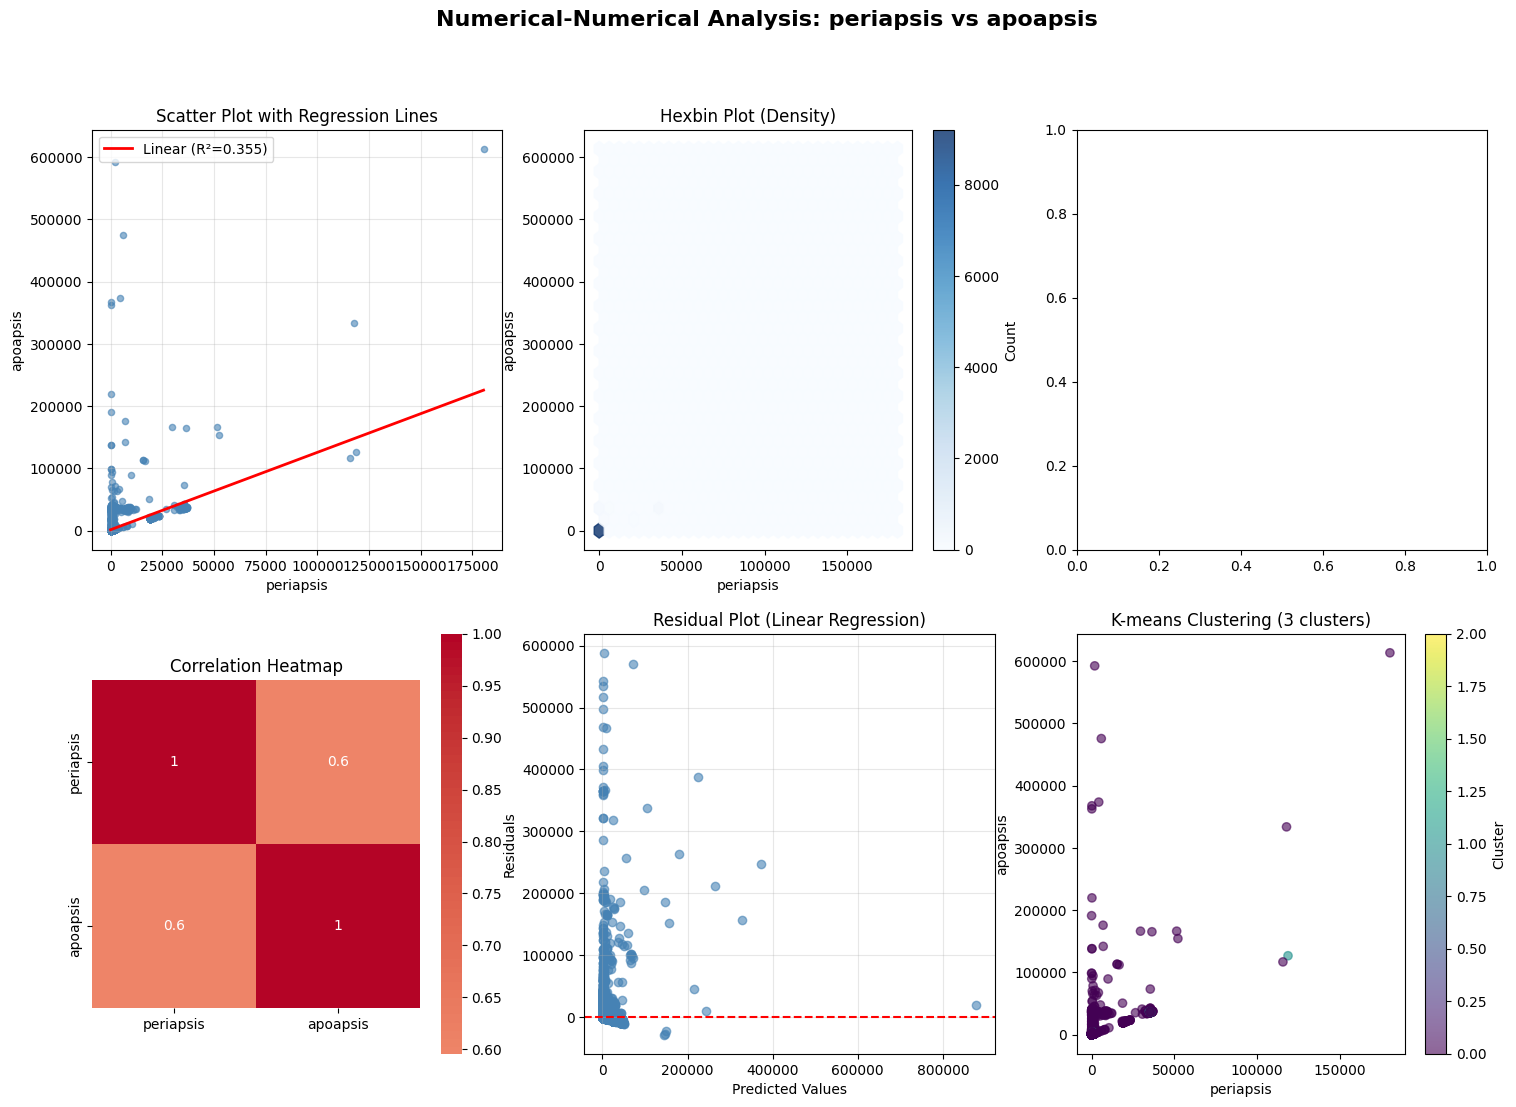

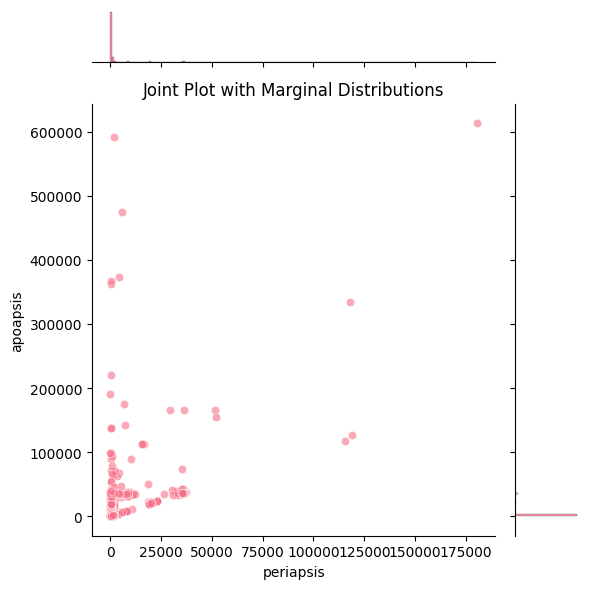


📋 SUMMARY:
   • Total observations: 65088
   • Valid observations: 64125
   • periapsis range: -218.16 - 705392.18
   • apoapsis range: 0.00 - 897754.42
   • Pearson correlation: 0.5958 (Moderate)
   • Spearman correlation: 0.8481 (Strong)


In [13]:
results = analyze_numerical_numerical(satnav_tidy, 'periapsis', 'apoapsis', plot_type='all')


In [72]:
# ===== MINIMAL BAR CHART RACE WITH GIF EXPORT (SQUARE, FIXED BYTES→ARRAY) =====
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import imageio.v2 as imageio
from pathlib import Path
from colorsys import hsv_to_rgb
from io import BytesIO
from PIL import Image  # <-- used to decode PNG bytes from plotly/kaleido

# --- Data preparation with cumulative sum ---
def prep_data(df, category_col, year_col):
    """Prepare data with cumulative counts"""
    d = df[[category_col, year_col]].dropna().copy()
    d[year_col] = d[year_col].astype(int)
    pivot = (d.assign(count=1)
               .pivot_table(index=year_col, columns=category_col, values="count",
                            aggfunc="size", fill_value=0))
    return pivot.cumsum()

# --- Helper: convert plotly PNG bytes → numpy RGBA array ---
def png_bytes_to_array(png_bytes):
    im = Image.open(BytesIO(png_bytes)).convert("RGBA")  # ensure 4 channels
    return np.array(im)

# --- Create bar race with GIF export (square) ---
def create_bar_race_gif(df, category_col, year_col,
                        top_n=8,
                        output_path="outputs/bar_race.gif",
                        size=600,              # square dimension (px)
                        frame_duration=100):   # ms per frame (10 fps = 100ms)
    """Create minimal bar race chart and export as a square GIF"""

    # 1) Data
    pivot_cum = prep_data(df, category_col, year_col)
    years = pivot_cum.index.tolist()

    # Keep Top-N by final cumulative
    top_categories = (pivot_cum.iloc[-1]
                      .sort_values(ascending=False)
                      .head(top_n).index.tolist())
    pivot_top = pivot_cum[top_categories]

    # x-axis max with padding
    x_max = float(pivot_top.values.max()) * 1.05

    # Distinct colors (HSV fallback)
    colors = []
    for i in range(len(top_categories)):
        r, g, b = hsv_to_rgb(i/len(top_categories), 0.8, 0.9)
        colors.append(f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}")
    color_map = {cat: colors[i] for i, cat in enumerate(top_categories)}

    # Year badge
    def year_badge(y):
        return [dict(
            text=f"<b>{y}</b>",
            x=0.95, y=0.95, xref="paper", yref="paper",
            showarrow=False,
            font=dict(color="#DEFF9A", size=18, family="Arial, sans-serif"),
            align="right",
            bgcolor="rgba(0,0,0,0.0)",  # transparent; clean look
            bordercolor="#DEFF9A",
            borderwidth=0
        )]

    # 2) Initial frame
    y0 = years[0]
    v0 = pivot_top.loc[y0].sort_values(ascending=True)
    fig = go.Figure(data=[
        go.Bar(
            x=v0.values,
            y=v0.index,
            orientation='h',
            text=[f"{int(val):,}" for val in v0.values],
            textposition='outside',
            textfont=dict(color='white', size=12),
            marker=dict(color=[color_map[cat] for cat in v0.index])
        )
    ])
    fig.update_layout(
        paper_bgcolor='black',
        plot_bgcolor='black',
        showlegend=False,
        width=size, height=size,   # square canvas
        margin=dict(l=90, r=30, t=40, b=60),
        font=dict(color='white', family="Arial, sans-serif", size=11),
        xaxis=dict(
            title="Cumulative Count",
            tickfont=dict(color='white'),
            tickformat=",d",
            range=[0, x_max],
            gridcolor="rgba(255,255,255,0.4)", gridwidth=1,
            zeroline=False
        ),
        yaxis=dict(
            tickfont=dict(color='white'),
            title=None,
            showgrid=False
        ),
        annotations=year_badge(y0),
        updatemenus=[], sliders=[]
    )

    # 3) Frames
    frames = []
    for y in years:
        vy = pivot_top.loc[y].sort_values(ascending=True)
        frames.append(go.Frame(
            data=[go.Bar(
                x=vy.values,
                y=vy.index,
                orientation='h',
                text=[f"{int(val):,}" for val in vy.values],
                textposition='outside',
                textfont=dict(color='white', size=12),
                marker=dict(color=[color_map[cat] for cat in vy.index])
            )],
            name=str(y),
            layout=go.Layout(
                xaxis=dict(range=[0, x_max]),
                annotations=year_badge(y)
            )
        ))
    fig.frames = frames

    # 4) Export as GIF (convert bytes → arrays)
    out = Path(output_path)
    out.parent.mkdir(parents=True, exist_ok=True)

    images = []
    # initial
    images.append(png_bytes_to_array(
        pio.to_image(fig, format="png", width=size, height=size, scale=2)
    ))
    # frames
    for fr in fig.frames:
        if fr.layout: fig.update_layout(fr.layout)
        if fr.data:   fig.update_traces(fr.data[0])
        images.append(png_bytes_to_array(
            pio.to_image(fig, format="png", width=size, height=size, scale=2)
        ))

    imageio.mimsave(str(out), images, duration=frame_duration/1000.0)  # e.g., 0.1s/frame = 10fps
    print(f"✅ GIF saved: {out} | frames={len(images)} | duration≈{len(images)*frame_duration/1000:.1f}s")

    return fig


In [73]:
fig = create_bar_race_gif(
    satnav_tidy,                # your dataframe
    category_col="object_type", # or "COUNTRY"
    year_col="LAUNCH_YEAR",
    top_n=10,
    output_path="outputs/bar_race_square.gif",
    size=600,                   # 600×600 px
    frame_duration=100          # 10 fps; keep total < ~18s by trimming years or increasing duration
)
fig.show()  # optional interactive preview


Python(75679) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75702) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75724) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75749) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75768) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75786) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75809) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75826) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75845) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75868) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(75885) Malloc

✅ GIF saved: outputs/bar_race_square.gif | frames=70 | duration≈7.0s
